# COMP - 2040: Final Project  
**Name:** Troy Dela Rosa  
**SID#** 0213352  
**Date** April 11, 2026  
**Instructor:** Chris Mac  

## 1. Introduction

### How Instructor Feedback Changed This Project

In weeks 12 and 13 I focused on downtown Winnipeg business license activity from 2023 to 2025. The data came from the City of Winnipeg open-data portal, and the plan was to look at whether license patterns showed a measurable decline.

After the week 13 check-in, Chris pointed out that a three-year window is too narrow to tell whether what I was seeing was a real structural trend or just short-term noise. He suggested pushing the timeline back as far as the data would allow.

That feedback changed the project in a big way. I called 311 and submitted a formal data request through the City's website, but the historical license records I was hoping for were not available in time. Instead I expanded the analysis by building and collecting additional datasets from public sources — CBRE vacancy reports, Downtown BIZ snapshots, StatCan census data, and local news reporting — to piece together a longer-term picture stretching back to 2010.

The result is a project that no longer just asks *"is downtown declining?"* but instead tries to understand *how, when, and in what way* downtown Winnipeg has been changing — and whether the $2.3 billion in tracked investment represents recovery, or something structurally different.

### Central Argument

Downtown Winnipeg is not recovering in the traditional sense. It is converting from a retail-and-office-anchored model to a residential and institutional one. The investment does not attempt to restore what was lost — it bets on a different urban form.

### Three Analytical Questions

1. **How has the balance of Growth vs. Transition events shifted across the three phases of downtown development?**
2. **Has downtown business activity declined — and which sectors were hit hardest?**
3. **Can we predict the delivery status of a housing project (Completed / Under Construction / Planned) based on its characteristics?**|




> *This analysis uses exploratory data analysis and visualization to examine development activity, business activity, and vacancy trends in Downtown Winnipeg. Interpretations are exploratory — not causal claims.*

## 2. Data Sources and Research Design

### What datasets am I working with?

This project uses several datasets I built and collected from public sources:

- **`downtown_wpg_gantt_sourced_2026.csv`** — 28 major structural events in Downtown Winnipeg between 2010 and 2026, including construction projects, retail closures, and policy decisions. Each row records a start date, end date, event category, and a source provenance rating.
- **`housing_pipeline_2026.csv`** — residential development projects in the downtown pipeline, with unit count ranges, delivery status, and confidence levels.
- **`Business_Licenses_20260404.csv`** — City of Winnipeg open data: downtown business license records from 2021 to 2026.
- **`Winnipeg_Synthetic_License_Model_2010_2024.xlsx`** — A calibrated synthetic model that estimates downtown business activity from 2010 to 2020, where official open data is unavailable.
- **`downtown_wpg_sources_2026.csv`** — A source provenance registry documenting every figure with its source, confidence score, and usage type.

### Where does the data come from?

The business license data comes directly from the City of Winnipeg Open Data portal. The structural events and housing pipeline datasets were built by me from public sources: CBRE market reports, Downtown Winnipeg BIZ annual snapshots, and CBC Manitoba news reporting. The full source registry documents 53 sources.

### Data Layer Structure

Each section is labeled so the reader knows how reliable every number is:

| Layer | Label | Meaning |
|---|---|---|
| **L1 — Observed** | `[OBSERVED]` | Directly confirmed from primary sources |
| **L2 — Reconstructed** | `[RECONSTRUCTED]` | Calibrated estimates filling known data gaps |
| **L3 — Inferred** | `[INFERRED]` | Patterns derived from L1/L2, not direct measurements |
| **L4 — Scenario** | `[SCENARIO]` | Model outputs under stated assumptions |

## 3. Setup

In [99]:
# standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

# scikit-learn imports for prediction section
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# dark chart style — all charts inherit this
plt.rcParams.update({
    'figure.facecolor': '#0d0f14',
    'axes.facecolor':   '#161921',
    'axes.edgecolor':   '#2a2e3a',
    'axes.labelcolor':  '#e0ddd5',
    'text.color':       '#e0ddd5',
    'xtick.color':      '#8a8780',
    'ytick.color':      '#8a8780',
    'grid.color':       '#2a2e3a',
    'font.family':      'sans-serif',
    'font.size':        11,
    'figure.dpi':       120
})

# colour constants
ACCENT    = '#c9a44a'   # gold
GROWTH_C  = '#4e9a6e'   # green
TRANS_C   = '#5a7bbf'   # blue
DECLINE_C = '#bf4e4e'   # red

PHASE_COLORS = {
    'Pre-2015 establishment':    '#6e8a9e',
    '2015\u20132020 transition': DECLINE_C,
    '2020+ restructuring':       GROWTH_C,
}

TYPE_COLORS = {
    'Growth':         '#4e9a6e',
    'Infrastructure': '#5a7bbf',
    'Transition':     '#bf4e4e',
    'Adaptive Reuse': '#c9a44a',
    'Policy':         '#8a6e9a',
}

print("Ready.")

Ready.


### Helper Module — Week 14 Refactor

In Weeks 12–13, I had already created three reusable helper functions in `src/helpers.py`:

- `clean_column_names()` — standardizes column names using lowercase and underscores
- `create_is_closed()` — flags closed, cancelled, ceased, or vacant business licenses
- `filter_downtown()` — keeps only records in the Downtown Community Characterization Area

For Week 14, I expanded the helper module so the notebook would stay cleaner and more readable. In addition to the earlier functions, I added reusable functions for dataset previewing, Gantt cleaning, housing cleaning, business license cleaning, source-registry summarizing, and housing prediction preparation.

Some of the main Week 14 additions are:

- `preview_dataset()` — prints a reusable overview of dataset shape, types, missing values, and sample rows
- `assign_phase()` — assigns each Gantt event to a development phase based on start year
- `clean_gantt()` — prepares the structural events dataset for timeline and phase analysis
- `clean_housing()` — computes midpoint unit estimates and separates the model-ready housing rows
- `clean_business_licenses()` — standardizes, filters, and parses the downtown business license data
- `summarize_source_registry()` — summarizes the source provenance registry
- `prepare_housing_prediction_data()` — encodes and prepares the housing data for the prediction section

These functions are stored in `src/helpers.py` and imported into the notebook where needed. This keeps repeated preparation logic out of the notebook and makes the analysis sections easier to follow.

## 4. Data Overview

Before cleaning or analysing anything, I want to understand the basic shape of each dataset — how many rows, what the columns are, and where the missing values are.

In [100]:
import sys
import importlib
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sys.path.insert(0, '..')

import src.helpers
importlib.reload(src.helpers)

from src.helpers import (
    preview_dataset,
    clean_column_names,
    filter_downtown,
    summarize_business_license_overview,
    summarize_source_registry,
    clean_gantt,
    clean_housing,
    clean_business_licenses,
    prepare_housing_prediction_data,
    compute_phase_composition,
    plot_phase_composition,
    prepare_business_activity_index_data,
    plot_business_activity_index,
    prepare_vacancy_benchmark_data,
    plot_vacancy_benchmark,
    prepare_category_phase_matrix,
    plot_category_phase_matrix,
    prepare_residential_pipeline_plot_data,
    plot_residential_pipeline,
    prepare_investment_scale_data,
    plot_investment_scale,
    prepare_gantt_timeline_data,
    plot_gantt_timeline,
    prepare_spatial_event_data,
    plot_spatial_event_map,
    summarize_spatial_quadrants,
)

### 4.1 Gantt Sourced Dataset

In [101]:
gantt_raw = pd.read_csv('../data/downtown_wpg_gantt_sourced_2026.csv')

preview_dataset(
    gantt_raw,
    title='GANTT DATASET',
    preview_cols=['task_name', 'category', 'start_date', 'end_date', 'status', 'source_quality'],
    n=3
)

=== GANTT DATASET ===
Shape: (30, 12)

Columns and types:
task_name              object
category               object
type                   object
start_date             object
end_date               object
status                 object
row_type               object
source_quality         object
biz_fallback             bool
primary_source_id      object
secondary_source_id    object
source_note            object

Missing values per column:
task_name               0
category                0
type                    0
start_date              0
end_date               11
status                  0
row_type                0
source_quality          0
biz_fallback            0
primary_source_id       0
secondary_source_id     6
source_note             0

First 3 rows:
                       task_name       category start_date   end_date    status source_quality
 RBC Convention Centre expansion Infrastructure 2013-01-01 2016-03-31 Completed           weak
Canadian Museum for Human Rights Infr

In [102]:
print(gantt_raw['source_quality'].value_counts())
print()
print(gantt_raw['row_type'].value_counts())

source_quality
strong      12
weak         9
moderate     9
Name: count, dtype: int64

row_type
discrete     26
composite     4
Name: count, dtype: int64


#### 5 observations about the Gantt dataset:

1. The dataset contains **30 rows**, which confirms that it is a small, curated project-level dataset rather than a large raw administrative file. Most rows represent discrete structural events, but a few represent broader ongoing processes.

2. Both **`start_date`** and **`end_date`** are stored as text (`object`) rather than datetime values, so they need to be converted before any duration calculation or timeline plotting.

3. The **`end_date`** field has **11 missing values**, which likely correspond to projects or processes that are still ongoing. These missing values need to be handled explicitly so in-progress projects are not dropped from the analysis.

4. The dataset includes built-in source provenance. Of the 30 rows, **12 are rated strong**, **9 moderate**, and **9 weak** on `source_quality`, which makes it possible to distinguish more strongly sourced events from weaker ones in later interpretation.

5. The **`row_type`** field shows that **26 rows are discrete events** and **4 are composite rows**. This matters because composite process rows can be useful for narrative context, but they may distort event counts if they are treated the same way as individual projects.

### 4.2 Housing Pipeline Dataset

In [103]:
housing_raw = pd.read_csv('../data/housing_pipeline_2026.csv', encoding='utf-8-sig')

preview_dataset(
    housing_raw,
    title='HOUSING PIPELINE',
    preview_cols=['project', 'units_low', 'units_high', 'phase_status', 'confidence', 'source_quality'],
    n=len(housing_raw)
)

=== HOUSING PIPELINE ===
Shape: (8, 18)

Columns and types:
project                   object
location                  object
units_low                  int64
units_high                 int64
unit_type                 object
phase_status              object
type                      object
row_type                  object
completion_window         object
completion_year_low        int64
completion_year_high       int64
confidence                object
include_in_model            bool
model_exclusion_reason    object
source_quality            object
primary_source_id         object
secondary_source_id       object
notes                     object

Missing values per column:
project                   0
location                  0
units_low                 0
units_high                0
unit_type                 0
phase_status              0
type                      0
row_type                  0
completion_window         0
completion_year_low       0
completion_year_high      0
confidence

#### 5 observations about the housing pipeline dataset:  

1. The dataset contains **8 rows and 18 columns**, which confirms that this is a small, curated project-level dataset focused on major downtown housing developments rather than a full inventory of all residential activity.

2. The unit fields are already numeric. Both **`units_low`** and **`units_high`** are stored as integers, which makes it easy to calculate midpoint estimates and compare project scale across developments.

3. The target-style delivery field, **`phase_status`**, has three clear categories: **Completed**, **Under Construction**, and **Planned**. This makes the dataset suitable for both descriptive analysis and a simple classification workflow.

4. The dataset includes built-in quality and uncertainty fields. **`confidence`** captures how certain the project estimate is, while **`source_quality`** records how strongly each row is supported by public sourcing. These are useful because not all future-oriented housing entries are equally certain.

5. One row is clearly different from the others: **“Other downtown infill / small sites (aggregate)”** is an aggregate estimate rather than a named individual project. That is why the dataset includes an **`include_in_model`** flag and a **`model_exclusion_reason`** field, allowing that row to be separated from the model-ready project set.

### 4.3 Business Licenses Dataset

In [104]:
biz_raw = pd.read_csv('../data/Business_Licenses_20260404.csv', encoding='cp1252', low_memory=False)
downtown_peek = filter_downtown(clean_column_names(biz_raw))

print(f"Total file rows: {len(biz_raw)}")
summarize_business_license_overview(downtown_peek)

Total file rows: 7313
=== BUSINESS LICENSES (downtown only) ===
Downtown rows:   2231

Columns:
['folder_type', 'folder_description', 'subdescription', 'trade_name', 'address', 'issue_date', 'expiry_date', 'status', 'neighbourhood_number', 'neighbourhood_name', 'electoral_ward', 'community_characterization_area', 'location']

Status values:
status
Closed (L)          1538
Issued               621
Ceased Operation      41
Cancelled             28
Vacant                 2
Review (L)             1

Issue Date sample (raw format):
0    2023 May 10 12:00:00 AM
1    2022 May 10 12:00:00 AM
2    2023 May 10 12:00:00 AM


#### 5 observations about the business license dataset:

1. The full business license file contains **7,313 rows**, of which **2,231** are in the **Downtown** community characterization area. This means the downtown subset is large enough to support trend analysis for recent years.

2. The dataset includes useful business activity fields such as **Folder Type**, **Folder Description**, **Trade Name**, **Issue Date**, **Expiry Date**, **Status**, and location-related columns. These fields make it possible to examine status patterns, timing, and sector-level activity.

3. The **Status** field is heavily dominated by **Closed (L)** entries (**1,538 rows**), followed by **Issued** (**621 rows**). This suggests that the downtown subset includes a large number of inactive or ended licenses and will need careful interpretation when used as a business activity signal.

4. The **Issue Date** field is still stored as text in its raw format, for example **“2023 May 10 12:00:00 AM”**, so it needs to be parsed into datetime format before extracting years or building time-based charts.

5. **This dataset is useful for measuring **recent downtown business conditions**, but it does not provide full historical coverage back to `2010`. That limitation is why the notebook uses a reconstructed pre-2021 business activity series rather than relying on open data alone for the entire study period.**

### 4.4 Sources Dataset

In [105]:
sources = pd.read_csv('../data/downtown_wpg_sources_2026.csv', encoding='utf-8-sig')
summarize_source_registry(sources)

Total sources: 53
  Core inputs (directly feed model): 15
  Model-ready:                       22
  Corroboration sources:             9

By source category:
source_category
news           28
market_data    13
official        9
background      3


#### 5 observations about the source registry:

1. The project source registry contains **53 total sources**, which shows that the notebook is built from a broad multi-source evidence base rather than a single dataset.

2. Of those 53 sources, **15 are core inputs** that directly feed the analysis or model construction, while **22 are marked model-ready**. This shows that not every collected source is treated equally in the final analytical workflow.

3. The registry also includes **9 corroboration sources**, which are useful for validating dates, costs, or interpretations even when they do not directly drive a chart or model input.

4. The source mix is dominated by **news sources (28)**, followed by **market data (13)** and **official sources (9)**. This reflects the reality of the topic: many structural downtown events are documented through reporting and announcements rather than through a single official administrative dataset.

5. Because the source base is mixed, source quality and evidence labeling are especially important. The registry supports the notebook’s layered design by helping distinguish directly observed facts from reconstructed, inferred, or scenario-based elements.

> **New sources added (Jan 2026):**
> - CBC News. "St. Charles Hotel slated to become 11-storey residential tower." Jan 27, 2026. `[strong, L1, core_input]` — https://www.cbc.ca/news/canada/manitoba/centreventure-winnipeg-downtown-housing-heritage-buildings-9.7063117
> - chrisd.ca. "Nearly 300 New Housing Units Planned for Downtown Winnipeg." Jan 27, 2026. `[moderate, L1, corroboration]` — https://www.chrisd.ca/2026/01/27/downtown-winnipeg-housing-units-redevelopment-centreventure/
> - Residents of the Exchange District. "Towering High Over Maw's Garage." Apr 17, 2025. `[moderate, background]` — https://www.residentsoftheexchangedistrict.ca/post/towering-high-over-maws-garage


### 4.5 Synthetic Business Activity Datase

In [106]:
synthetic_doc = pd.read_excel('../data/Winnipeg_Synthetic_License_Model_2010_2024.xlsx')

preview_dataset(
    synthetic_doc,
    title='SYNTHETIC BUSINESS ACTIVITY MODEL (DOCUMENTATION SHEET)',
    n=5
)

=== SYNTHETIC BUSINESS ACTIVITY MODEL (DOCUMENTATION SHEET) ===
Shape: (9, 2)

Columns and types:
Downtown Winnipeg Business License      object
Synthetic Continuity Model 2010–2024    object

Missing values per column:
Downtown Winnipeg Business License      1
Synthetic Continuity Model 2010–2024    1

First 5 rows:
Downtown Winnipeg Business License                                                               Synthetic Continuity Model 2010–2024
                               NaN                                                                                                NaN
                           PURPOSE       Gap-fill reconstruction for missing municipal license records 2010–2021. NOT real City data.
                       METHODOLOGY     Calibrated using CBRE vacancy series, BIZ reports, Statistics Canada census, and known events.
                        CONFIDENCE          High for 2022–2024 (open data anchor). Medium for 2015–2021. Low/synthetic for 2010–2014.
           

#### 5 observations about the synthetic business activity model file:

1. The workbook functions as a **documentation sheet rather than a row-level analytical dataset**. Instead of yearly business records, it contains notes describing the purpose, methodology, confidence, and limitations of the synthetic reconstruction.

2. Both columns are stored as **text (`object`)**, which confirms that this sheet is descriptive and not directly usable as a numeric time-series table.

3. The file clearly states that the synthetic continuity model is a **gap-fill reconstruction for missing municipal license records from 2010 to 2021** and is **not real City data**. This is an important methodological limitation and should stay visible throughout the notebook.

4. The built-in confidence note is especially useful because it distinguishes stronger and weaker parts of the reconstruction: **high confidence for 2022–2024**, **medium confidence for 2015–2021**, and **low/synthetic confidence for 2010–2014**.

5. The sheet also documents the reason the synthetic model was needed in the first place: a **10-year City of Winnipeg records retention limit** created a historical data gap, so the synthetic series was used as a transparent workaround rather than a substitute for official historical records.

## 5. Data Cleaning

This section documents every cleaning step and explains *why* it was needed - not just what was done.

### 5.1 Gantt Dataset Cleaning

In [107]:
# Clean the Gantt dataset using the helper module
gantt_raw = pd.read_csv('../data/downtown_wpg_gantt_sourced_2026.csv')

missing_before = gantt_raw['end_date'].isna().sum()
gantt = clean_gantt(gantt_raw, today='2026-04-13')

print(f"Filled {missing_before} missing end dates -> 2026-04-13")
print(f"\nGantt cleaned: {len(gantt)} rows, {gantt.isnull().sum().sum()} remaining nulls in key columns")

Filled 11 missing end dates -> 2026-04-13

Gantt cleaned: 30 rows, 6 remaining nulls in key columns


#### Cleaning Summary

- The Gantt dataset was cleaned successfully and is now ready for timeline-based analysis. A total of **11 missing `end_date` values** were filled with **April 13, 2026**, which represents the data collection date rather than a true completion date. This step allows ongoing projects to remain in the analysis instead of being dropped during duration calculations.  

- After cleaning, the dataset contains **30 rows**. New fields were added to support later analysis, including project duration in days, extracted start and end years, a phase label based on start year, a simplified impact grouping, and a completion flag for chart styling.  

- There are still **6 remaining null values** in the dataset, but these are not in the main fields needed for timeline construction. The core date and classification columns are now usable, so the dataset is in good shape for the event timeline and phase-based analysis.

### 5.2 Housing Pipeline Cleaning

In [108]:
# Clean the housing pipeline using the helper module
housing_raw = pd.read_csv('../data/housing_pipeline_2026.csv', encoding='utf-8-sig')
housing, housing_model = clean_housing(housing_raw)

print(f"Total rows:      {len(housing)}")
print(f"Model-ready:     {len(housing_model)}")
print(f"Excluded row:    {housing[~housing['include_in_model']]['project'].values}")
print(f"\nphase_status values: {sorted(housing['phase_status'].unique())}")
print(f"\nconfidence values:   {sorted(housing['confidence'].unique())}")

Total rows:      8
Model-ready:     7
Excluded row:    ['Other downtown infill / small sites (aggregate)']

phase_status values: ['Completed', 'Planned', 'Under Construction']

confidence values:   ['high', 'low_medium', 'medium', 'medium_high']


#### Cleaning Summary

The housing pipeline dataset contains **8 total rows**, of which **7 were kept as model-ready projects**. One row, **“Other downtown infill / small sites (aggregate)”**, was excluded because it represents a grouped estimate rather than a clearly identifiable, source-specific project. Keeping it out of the model-ready set helps preserve project-level consistency and avoids mixing named developments with broad approximations.

The cleaned dataset includes three project status categories: **Completed**, **Planned**, and **Under Construction**. This makes the file suitable for both descriptive analysis and a simple classification example later in the notebook.

The confidence field also shows different certainty levels, ranging from **high** to **low_medium**. That variation matters because the housing pipeline is forward-looking, and not all projects are equally certain. Overall, the cleaning step produced a small but usable project-level dataset for analyzing downtown residential delivery and future supply.

### 5.3 Business License Dataset Cleaning

In [109]:
biz_raw = pd.read_csv('../data/Business_Licenses_20260404.csv', encoding='cp1252', low_memory=False)
biz = clean_business_licenses(biz_raw)

print(f"Downtown records kept: {len(biz)}")
print(f"Year range:            {int(biz['year'].min())} – {int(biz['year'].max())}")

Downtown records kept: 2231
Year range:            2021 – 2026


#### Cleaning Summary

After filtering the full file to the study area, **2,231 downtown business license records** were retained for analysis.

The cleaned downtown subset covers a **year range from 2021 to 2026**, which provides a recent multi-year window for examining business activity, closures, and license status patterns. This is useful for measuring current conditions, but it also confirms one of the project’s core limitations: the official open data does not extend far enough back to analyze the full 2010–2026 structural transition on its own.

Overall, the business license data is now ready for time-based analysis of recent downtown conditions. It serves as the strongest directly observed business activity source in the notebook, while earlier years still rely on reconstructed trend estimates.

### Overall Cleaning Summary

| Dataset | Problem | Fix | Why |
|---|---|---|---|
| Gantt | Missing `end_date` values for in-progress rows | Filled missing values with **April 13, 2026** | Allows duration calculations while clearly treating these as still ongoing at the time of data collection |
| Gantt | No `phase`, `impact`, or `is_done` fields | Derived new columns from existing date, category, and status fields | Required to support phase analysis, impact grouping, and Gantt chart styling |
| Housing | Unit counts stored as ranges | Computed a midpoint estimate, `units_mid` | Provides a single comparable numeric value for charts and simple modeling |
| Housing | One aggregate row mixed with named project rows | Separated into `housing_model` and excluded the aggregate row from project-level modeling | Prevents unverifiable grouped estimates from distorting project-level analysis |
| Business licenses | Dates stored as non-standard strings | Parsed dates using an explicit format string | Makes year extraction and time-based trend analysis possible |
| Business licenses | Citywide records included in the raw file | Filtered to `Downtown` records only | Keeps the dataset aligned with the project’s downtown-only scope |

Overall, the cleaning process focused on making each dataset analytically usable while preserving transparency about assumptions, derived fields, and excluded records. These steps were necessary to support consistent comparison across the **three core analytical datasets** and to ensure that later visualizations and interpretations were based on usable, defensible inputs.

## 6. Exploratory Analysis

### Visualization 1 - Phase Composition `[L1 - OBSERVED]`

How has the mix of Growth vs. Transition events shifted across three phases of downtown development? Only discrete events are counted - composite/process rows are excluded.  


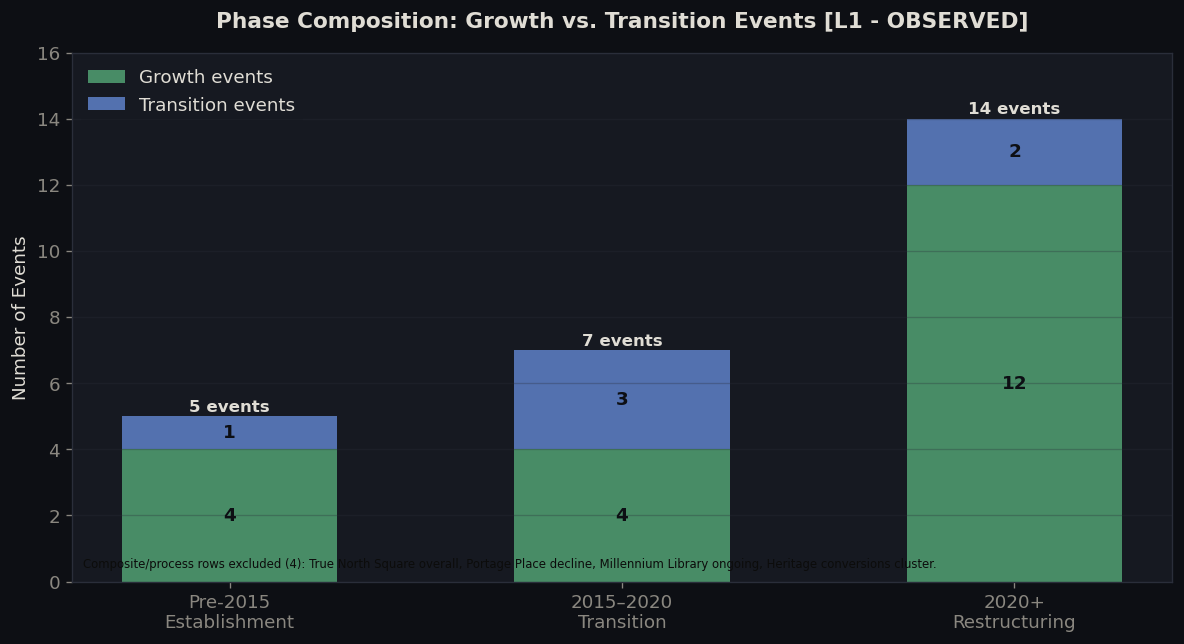

In [110]:
growth_vals, trans_vals, phases = compute_phase_composition(gantt)

phase_labels = [
    "Pre-2015\nEstablishment",
    "2015–2020\nTransition",
    "2020+\nRestructuring"
]

fig, ax = plot_phase_composition(
    growth_vals=growth_vals,
    trans_vals=trans_vals,
    phase_labels=phase_labels,
    growth_color=GROWTH_C,
    transition_color=TRANS_C,
    save_path="../visuals/fig_phase_composition.png"
)

plt.show()

#### Key Findings & Why this matters - Phase Composition `[L1]`

- The **2020+ restructuring phase** has the highest discrete event count, driven mainly by Growth-classified events
- The **2015–2020 transition phase** is relatively mixed, with Growth and Transition events occurring side by side as major investment coexisted with retail and commercial disruption
- **Pre-2015** is anchored primarily by civic and institutional infrastructure, including the CMHR, RBC Convention Centre expansion, and the return of the Jets

> **Why this matters:** The shift toward Growth-classified events in the 2020+ phase does not automatically mean commercial conditions are improving. Many of these events represent structural *conversion* rather than traditional expansion, such as retail anchor to residential or vacant office to institutional use. Positive investment signals do not necessarily translate into immediate economic recovery. That distinction is central to the interpretation that follows.

### Visualization 2 - Business License Activity (2010–2024) `[L1 (2021+) / L2 (2010–2020)]`

This section shows downtown business activity trends. **The data is indexed to 2013=100** so that relative trajectory is visible without implying precision in the absolute counts pre-2021.  

Index base: 2013 = 100
2024 indices — Retail: 36.8  Office: 56.6  Food: 65.6


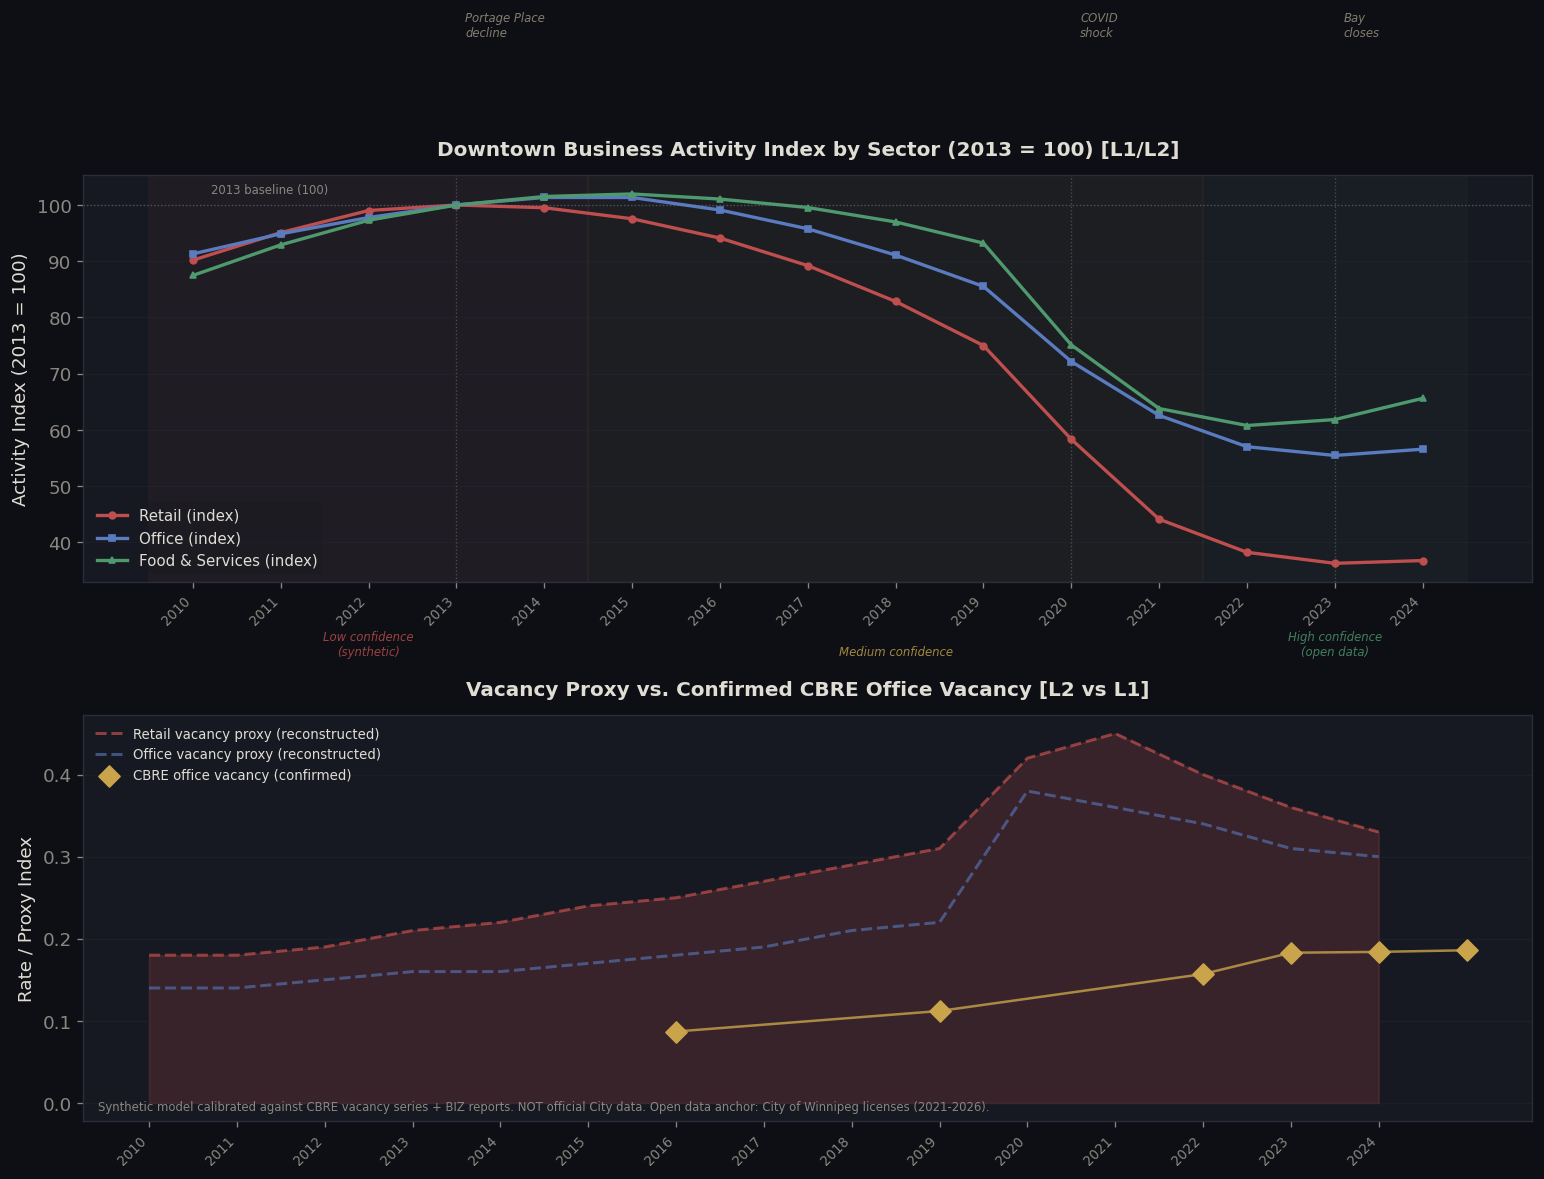

In [111]:
retail, office, food, syn, base_year = prepare_business_activity_index_data(
    '../data/Winnipeg_Synthetic_License_Model_2010_2024.xlsx',
    base_year=2013
)

print(f"Index base: {base_year} = 100")
print(
    f"2024 indices — Retail: {retail.loc[retail['Year']==2024, 'idx'].values[0]:.1f}  "
    f"Office: {office.loc[office['Year']==2024, 'idx'].values[0]:.1f}  "
    f"Food: {food.loc[food['Year']==2024, 'idx'].values[0]:.1f}"
)

fig, axes = plot_business_activity_index(
    retail=retail,
    office=office,
    food=food,
    syn=syn,
    decline_color=DECLINE_C,
    transition_color=TRANS_C,
    growth_color=GROWTH_C,
    accent_color=ACCENT,
    save_path='../visuals/fig_business_activity.png'
)

plt.show()

#### Key Findings - Business Activity `[L1/L2]`

- The **retail activity index** fell from **100 in 2013** to about **37 by 2024**, indicating the steepest decline of the three sectors
- **Food & Services** shows the strongest post-2020 recovery, while **office activity** stabilizes somewhat but remains well below its earlier level
- The decline is not uniform across sectors: retail weakens most sharply, office declines more gradually, and Food & Services recovers modestly after the pandemic shock
- The lower panel shows that the reconstructed vacancy proxy follows the general direction of the confirmed **CBRE office vacancy** series, but it should still be treated as a directional support layer rather than a calibrated absolute measure
- Pre-2021 business activity values are **reconstructed estimates**, so the trend direction is more defensible than the exact magnitudes

> **Why this matters:** This figure shows why the downtown cannot be described by investment alone. Even while major capital projects move forward, current business activity remains weak, especially in retail. That does not necessarily contradict the investment story. It suggests that short-term commercial conditions and long-term structural redevelopment are operating on different timelines.

### Visualization 3 - Office Vacancy Rate with Seaborn (2016–2025) `[L1 - OBSERVED]`

Office vacancy is the most direct measure of short-term commercial health. It has doubled over nine years - and the trajectory has not yet reversed.

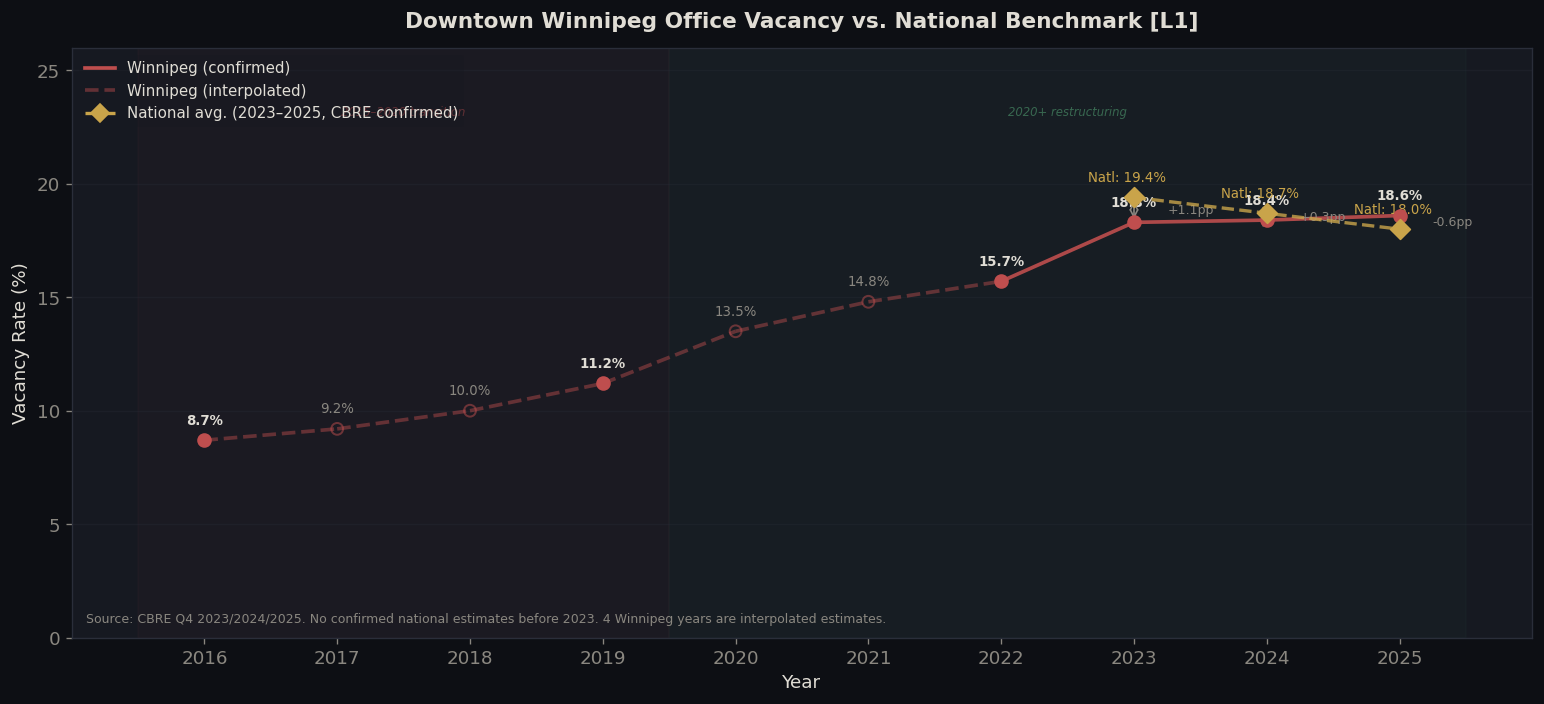

In [112]:
vac, national = prepare_vacancy_benchmark_data()

fig, ax = plot_vacancy_benchmark(
    vac=vac,
    national=national,
    decline_color=DECLINE_C,
    growth_color=GROWTH_C,
    accent_color=ACCENT,
    save_path='../visuals/fig_vacancy.png'
)

plt.show()

#### Key Findings - Office Vacancy `[L1]`

- Downtown Winnipeg office vacancy rose from **8.7% in 2016** to **18.6% in 2025**, meaning it more than doubled over the period shown
- Winnipeg remained **below** the national benchmark in **2023** and **2024**, but moved **above** it in **2025**
- The 2025 crossover is real, but it should be interpreted carefully because the national comparison is only available for three years
- Four Winnipeg values in the series are interpolated, so they should be treated as continuity estimates rather than directly sourced observations

> **Why this matters:** The chart shows that downtown office conditions remain materially weaker than they were a decade ago. At the same time, the comparison to the national benchmark suggests that Winnipeg’s trajectory is not explained by a simple local collapse narrative alone. The more accurate reading is that office weakness remains part of a broader restructuring process whose long-term outcome is still unresolved.

### Visualization 4 - Category × Phase Matrix `[L3 - INFERRED]`  

This heatmap asks how event categories are distributed across the three major downtown phases. Instead of reading the project as a timeline, this view turns the structural event dataset into a category-by-phase matrix so it is easier to see which kinds of events dominate each period.

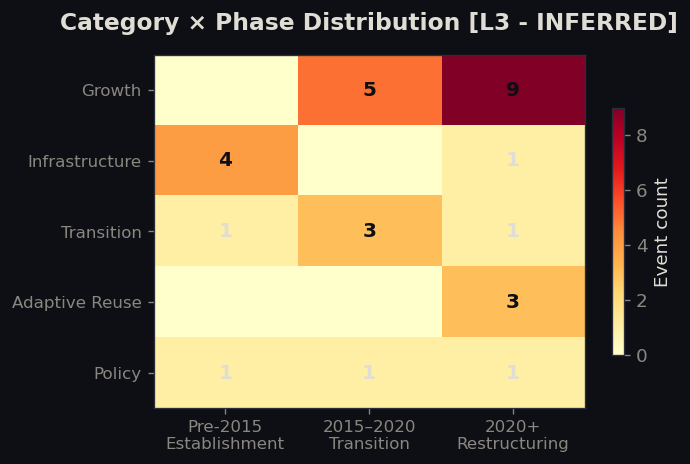

In [113]:
ct = prepare_category_phase_matrix(gantt)

fig, ax = plot_category_phase_matrix(
    ct,
    save_path='../visuals/fig_heatmap.png'
)

plt.show()

#### Key Findings - Category × Phase `[L3]`

- **Growth** events are most concentrated in the **2020+ restructuring** phase
- **Transition** events are most concentrated in the **2015–2020 transition** phase
- **Infrastructure** is concentrated mainly in the **Pre-2015** phase, with only limited presence afterward
- **Adaptive Reuse** appears almost entirely in the **2020+** phase, reinforcing the interpretation that recent investment is focused more on conversion than on traditional expansion

> **Why this matters:** The heatmap makes the phase story easier to read as a matrix rather than a timeline. The 2015–2020 concentration of Transition events aligns with the period of visible commercial disruption, while the 2020+ concentration of Growth and Adaptive Reuse events can be read as the structural response. This does not prove recovery, but it does support the interpretation that the downtown is being reshaped through conversion.

### Visualization 5 - Residential Pipeline `[L1/L2 - OBSERVED/RECONSTRUCTED]`

The residential pipeline is the forward-looking signal that gives the investment story its logic. Without a significant increase in downtown residents, the adaptive reuse conversions in Sections 3 and 6 cannot generate the organic ground-floor demand needed to reduce vacancy. This section quantifies what is committed, what is delivered, and what remains to be tested.

> **Note — January 2026 update:** On January 27, 2026, CentreVenture announced a further 297 units across four heritage building conversions, backed by $4.65M from the City of Winnipeg, the federal Housing Accelerator Fund, and the Gail Parvin Hammerquist Fund. The two largest are:
> - **St. Charles Hotel** (235 Notre Dame Ave) - 140-unit conversion of a vacant 113-year-old hotel, with 11-storey addition preserving the heritage facade. Developer: Ken Zaifman / Penfor Construction. `[L1 - OBSERVED, strong source: CBC News Jan 27 2026]`
> - **Maw's Garage / Sanford Building** (291 Bannatyne Ave) - 114-unit residential tower incorporating a 1907 garage and 1890 Sanford building in the Exchange District. Developer: Fratelli Enterprises / Sabino Tummillo. City heritage permit approved over HBRC objection. `[L1 - OBSERVED, strong source: CBC News Jan 27 2026; moderate corroboration: Residents of the Exchange District Apr 2025]`
>
> These projects are announced but not yet added to `housing_pipeline_2026.csv`. They are noted here as a confirmed pipeline addition. When incorporated, the model-ready unit range rises from 1,381-1,539 to approximately **1,635-1,793** (excluding the remaining 43 units across the Belgica Block and Alloway Building).


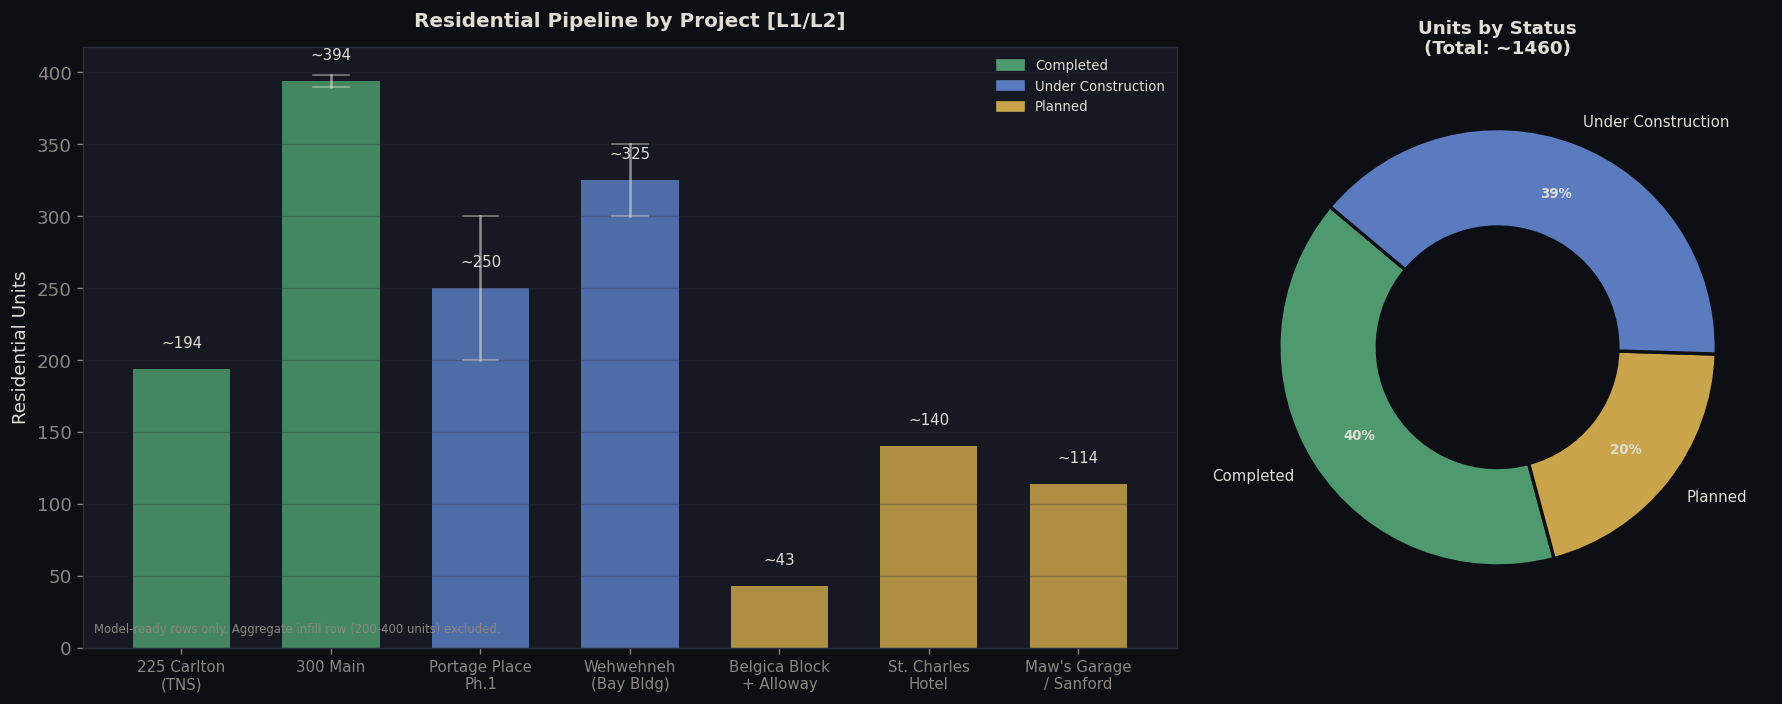

In [114]:
housing_model_plot, short_labels = prepare_residential_pipeline_plot_data(housing)

fig, (ax1, ax2) = plot_residential_pipeline(
    housing_model=housing_model_plot,
    short_labels=short_labels,
    growth_color=GROWTH_C,
    transition_color=TRANS_C,
    accent_color=ACCENT,
    save_path='../visuals/fig_residential.png'
)

plt.show()

#### Key Findings - Residential Pipeline `[L1/L2]`

- The current model-ready housing dataset contains approximately **1,381–1,539 units**, with a midpoint total of about **1,460 units**
- About **40%** of those midpoint units are already **delivered**, while the remaining majority are still **under construction or planned**
- The pipeline is concentrated in a small number of major projects, especially **300 Main**, **Wehwehneh**, and **Portage Place Phase 1**
- This means the residential demand story is partly visible already, but much of the expected downtown population growth is still future-oriented rather than fully realized

> **Why this matters:** This chart helps explain why large-scale investment and weak short-term commercial conditions can coexist. A substantial share of the residential supply that is supposed to support future ground-floor demand is either still being built or not yet delivered. The pipeline is real, but much of its street-level economic effect is still pending.

### Visualization 6 - Capital Investment Scale `[L1 - OBSERVED]`

The investment picture is the other half of the structural argument. If Section 5 shows the current weakness in commercial vitality, this section shows what is being bet against it - and crucially, *what kind* of bet it is.


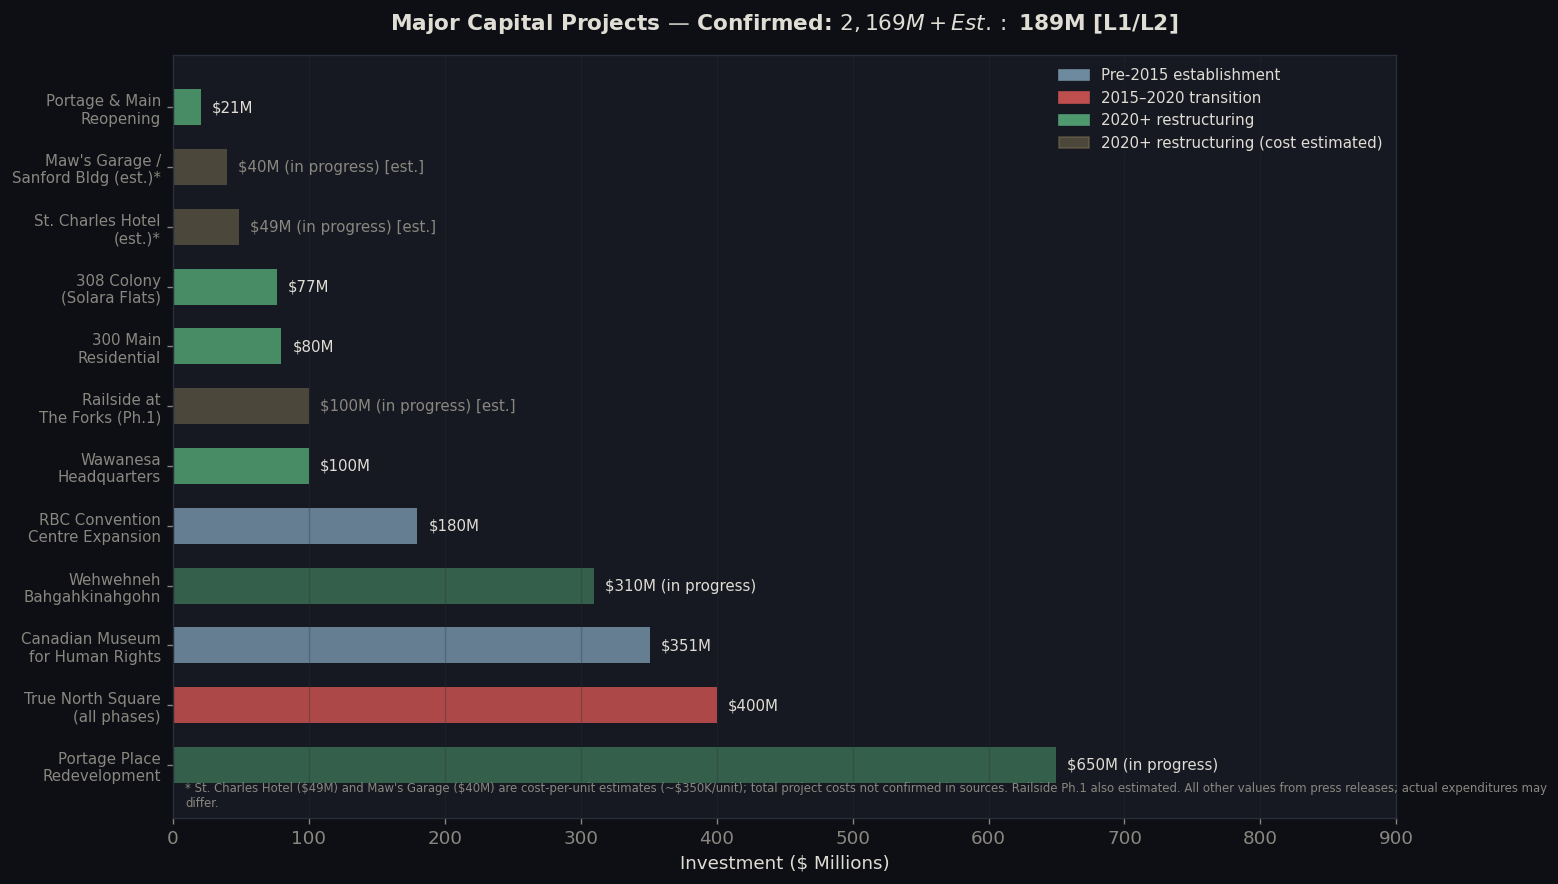

In [115]:
inv = prepare_investment_scale_data()

fig, ax = plot_investment_scale(
    inv=inv,
    phase_colors=PHASE_COLORS,
    save_path='../visuals/fig_investment.png'
)

plt.show()

#### Key Findings - Capital Investment `[L1/L2]`

- The tracked capital pipeline includes roughly **$2.17B in confirmed investment** plus about **$189M in estimated project costs**, for a combined total near **$2.36B**
- The largest projects are concentrated in the **2020+ restructuring** phase, especially **Portage Place redevelopment ($650M)** and **Wehwehneh Bahgahkinahgohn ($310M)**
- Several of the biggest projects are still **in progress**, which means the investment is committed but not yet fully delivered
- The estimated projects are clearly marked and should be interpreted more cautiously than the confirmed figures

> **Why this matters:** The scale of tracked capital shows that Downtown Winnipeg is not simply experiencing decline. At the same time, the composition of that investment matters just as much as the total. Much of the recent capital is going into adaptive reuse, residential conversion, and institutional restructuring rather than restoring the old retail-centered downtown model. This supports the project’s argument that downtown is being reconfigured, not simply rebuilt in its previous form.

### Visualization 7 - Project Timeline (Gantt View) `[L1/L2 - OBSERVED/RECONSTRUCTED]`

Every structural event mapped by duration. Bar opacity encodes source quality: full = strong source, faded = weak source.

The timeline makes the investment-vitality disconnect visible at a glance: the largest cluster of active projects sits in 2024–2026, yet all of them extend past the current data window. Capital is deployed. Delivery is pending.


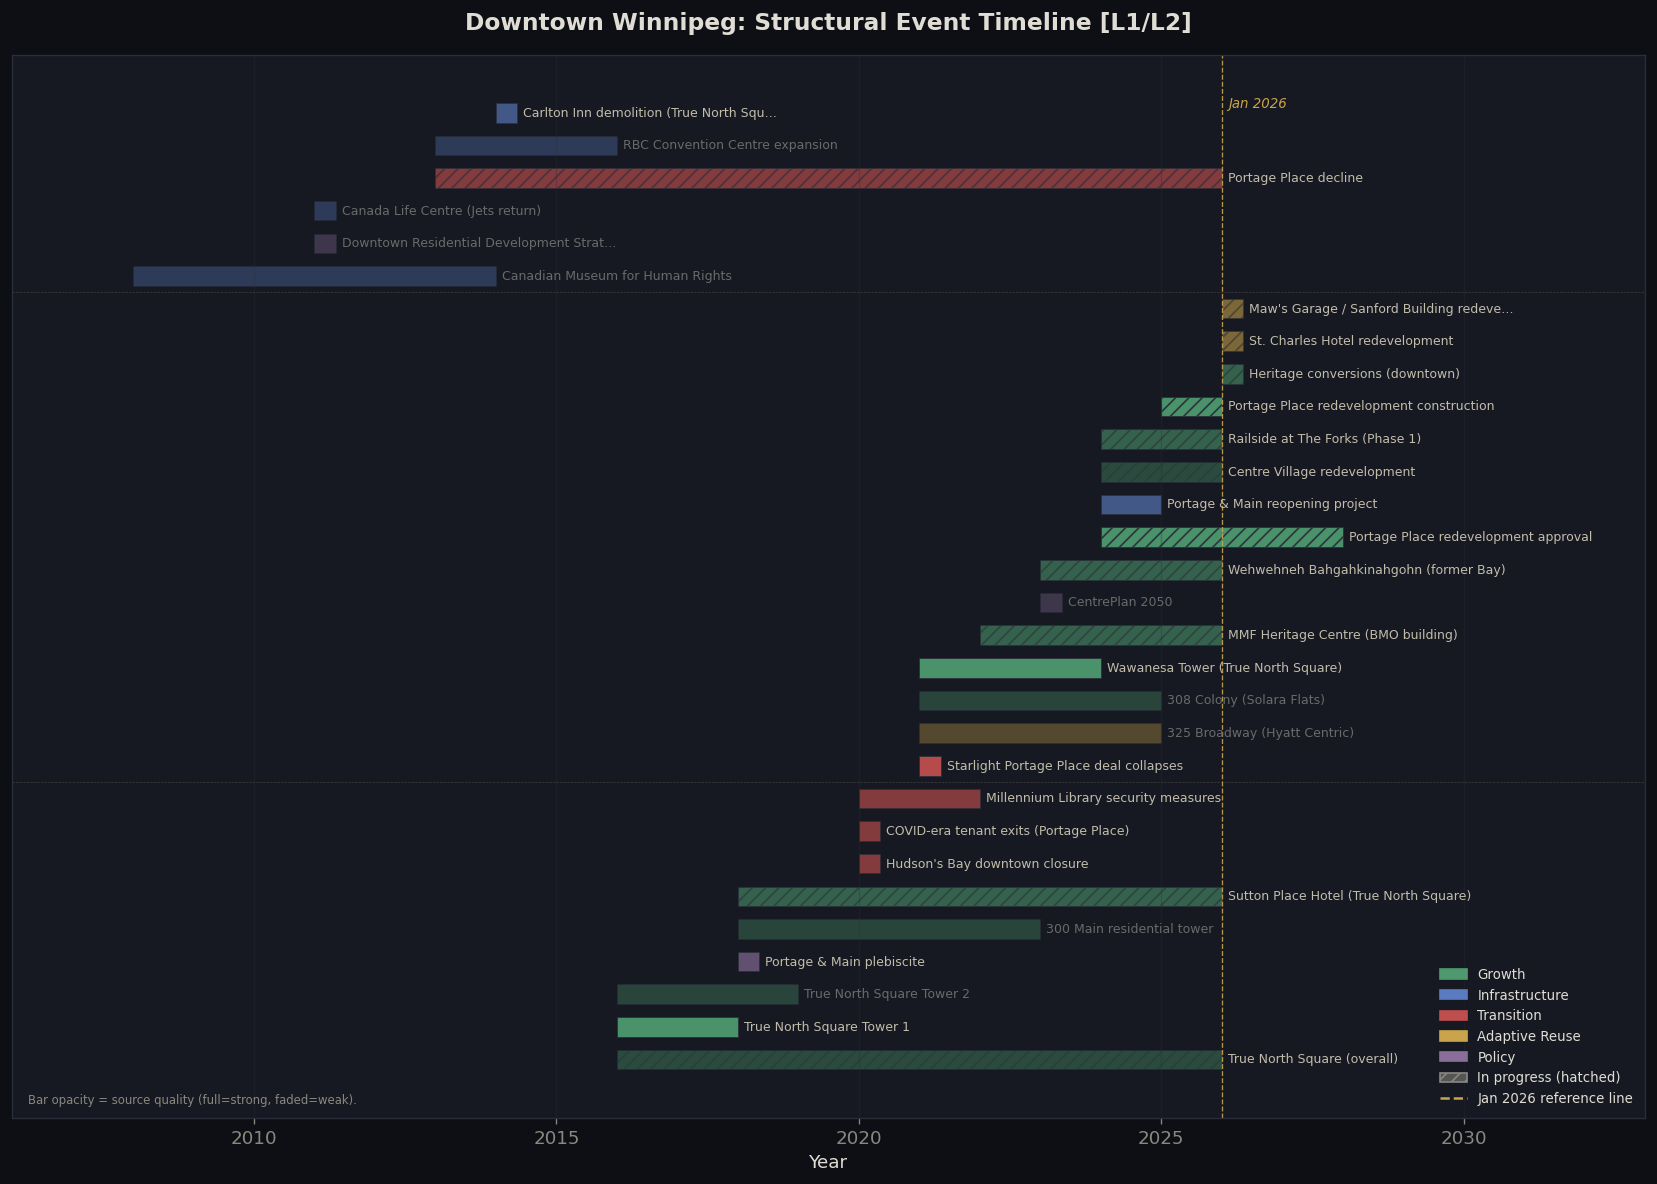

In [116]:
df_g = prepare_gantt_timeline_data(gantt)

fig, ax = plot_gantt_timeline(
    df_g=df_g,
    type_colors=TYPE_COLORS,
    accent_color=ACCENT,
    save_path='../visuals/fig_gantt.png'
)

plt.show()

#### Key Findings - Timeline `[L1/L2]`

- Construction and redevelopment activity is heavily concentrated in the post-2020 period, with the largest visible cluster active in 2024–2026
- Faded bars are concentrated more heavily among older events, showing that dedicated source quality is generally weaker for earlier timeline entries
- Several major projects remain in progress at the January 2026 reference line, showing that investment activity is ongoing even where final outcomes are not yet observable

> **Why this matters:** The concentration of hatched bars at and beyond the January 2026 reference line is not a gap in the dataset. It is the central empirical condition of this analysis. Investment is committed and construction is active, but many outcomes are still unresolved. This helps explain why high investment and weak downtown conditions can coexist: they reflect different stages of structural change.

### Visualization 8 - Spatial Distribution of Investment `[L1 - OBSERVED]`

Where are the projects located? This spatial plot maps major downtown events using project latitude and longitude coordinates to show where structural change is actually occurring across the core.  

This matters because investment is not distributed evenly across Downtown Winnipeg. Instead, it appears concentrated in specific redevelopment corridors, while other parts of downtown show fewer visible growth signals. That uneven geography is important for interpretation: aggregate indicators such as the Downtown Health Score can summarize the whole core, but they can also hide meaningful spatial differences between areas experiencing active transformation and areas still facing weaker conditions.

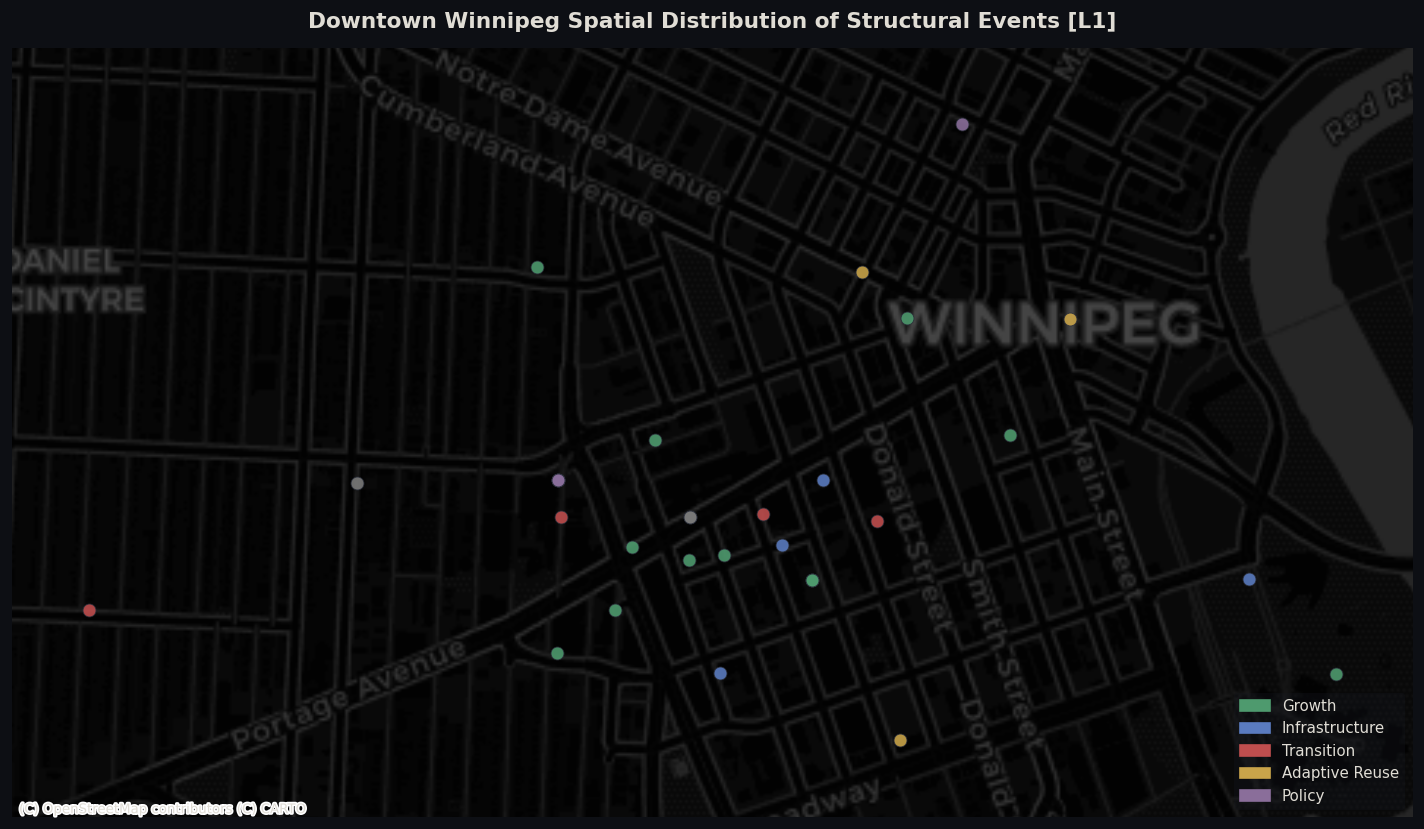

Projects per neighbourhood quadrant (by lon):
east_west        category        
East of -97.145  Adaptive Reuse       3
                 Growth               3
                 Infrastructure       1
                 Policy               1
                 Transition           1
West of -97.145  Growth              11
                 Infrastructure       4
                 Market Indicator     3
                 Policy               2
                 Transition           3


In [117]:
cat_color_map = {
    "Growth": "#4e9a6e",
    "Infrastructure": "#5a7bbf",
    "Transition": "#bf4e4e",
    "Adaptive Reuse": "#c9a44a",
    "Policy": "#8a6e9a",
}

df_spatial, gdf_spatial = prepare_spatial_event_data(
    "../data/winnipeg_downtown_projects_2026.csv",
    x_shift=120,
    y_shift=-20
)

fig, ax = plot_spatial_event_map(
    gdf=gdf_spatial,
    cat_color_map=cat_color_map,
    save_path="../visuals/fig_spatial.png"
)

plt.show()

summarize_spatial_quadrants(df_spatial)

#### Key Findings - Spatial Distribution `[L1]`

- Growth events are concentrated more heavily in the western side of the study area, especially around the Portage Avenue and True North Square corridor
- A secondary cluster is visible around 300 Main and the Forks / Railside area, showing that structural change is not limited to a single downtown block
- Transition events appear more spatially dispersed across the downtown core than Growth events

> **Why this matters:** A visitor standing at Portage and Main may observe an active construction and redevelopment corridor. A visitor in the East Exchange may observe a different downtown entirely. Both readings are valid, but neither captures the full picture. 

## 7. Downtown Health Score (DHS) Model `[L4 — SCENARIO]`

The DHS combines five indicators into a single scenario score intended to summarize downtown conditions under the assumptions used in this project. It is **not a direct measurement** and should be interpreted as a theory-based synthesis model. The weights are researcher-defined, and the final score depends entirely on how each component is constructed.

$$DHS = 0.25(\text{Business Stability}) + 0.25(\text{Residential Demand}) + 0.25(\text{Investment Pipeline}) + 0.15(\text{Spatial Anchoring}) - 0.10(\text{Vacancy Distress})$$

> **Important:** The DHS is not directly comparable across cities unless all five component scores are recalibrated to that city’s local context and market structure.


In [118]:
from src.helpers import compute_dhs

dhs_result = compute_dhs(housing)

print(f"Business Stability:  {dhs_result['business_stability']}/100  (25%)  — source: BIZ_2023_EOY")
print(f"Residential Demand:  {dhs_result['residential_demand']}/100  (25%)  — computed from pipeline")
print(f"Investment Pipeline: {dhs_result['investment_pipeline']}/100  (25%)  — source: CBC/CBRE")
print(f"Spatial Anchoring:   {dhs_result['spatial_anchoring']}/100  (15%)  — qualitative")
print(f"Vacancy & Distress:  {dhs_result['vacancy_distress']}/10   (-10%) — source: CBRE_WPG_Q4_2025")
print(f"\n{'='*45}")
print(f"DOWNTOWN HEALTH SCORE (DHS): {dhs_result['dhs']}/100")
print(f"Band: {dhs_result['band']}")

Business Stability:  42/100  (25%)  — source: BIZ_2023_EOY
Residential Demand:  92/100  (25%)  — computed from pipeline
Investment Pipeline: 78/100  (25%)  — source: CBC/CBRE
Spatial Anchoring:   72/100  (15%)  — qualitative
Vacancy & Distress:  8/10   (-10%) — source: CBRE_WPG_Q4_2025

DOWNTOWN HEALTH SCORE (DHS): 63.0/100
Band: Mixed/Transitional (50-64)


### 7.1 Component Gauges `[L4 - SCENARIO]`

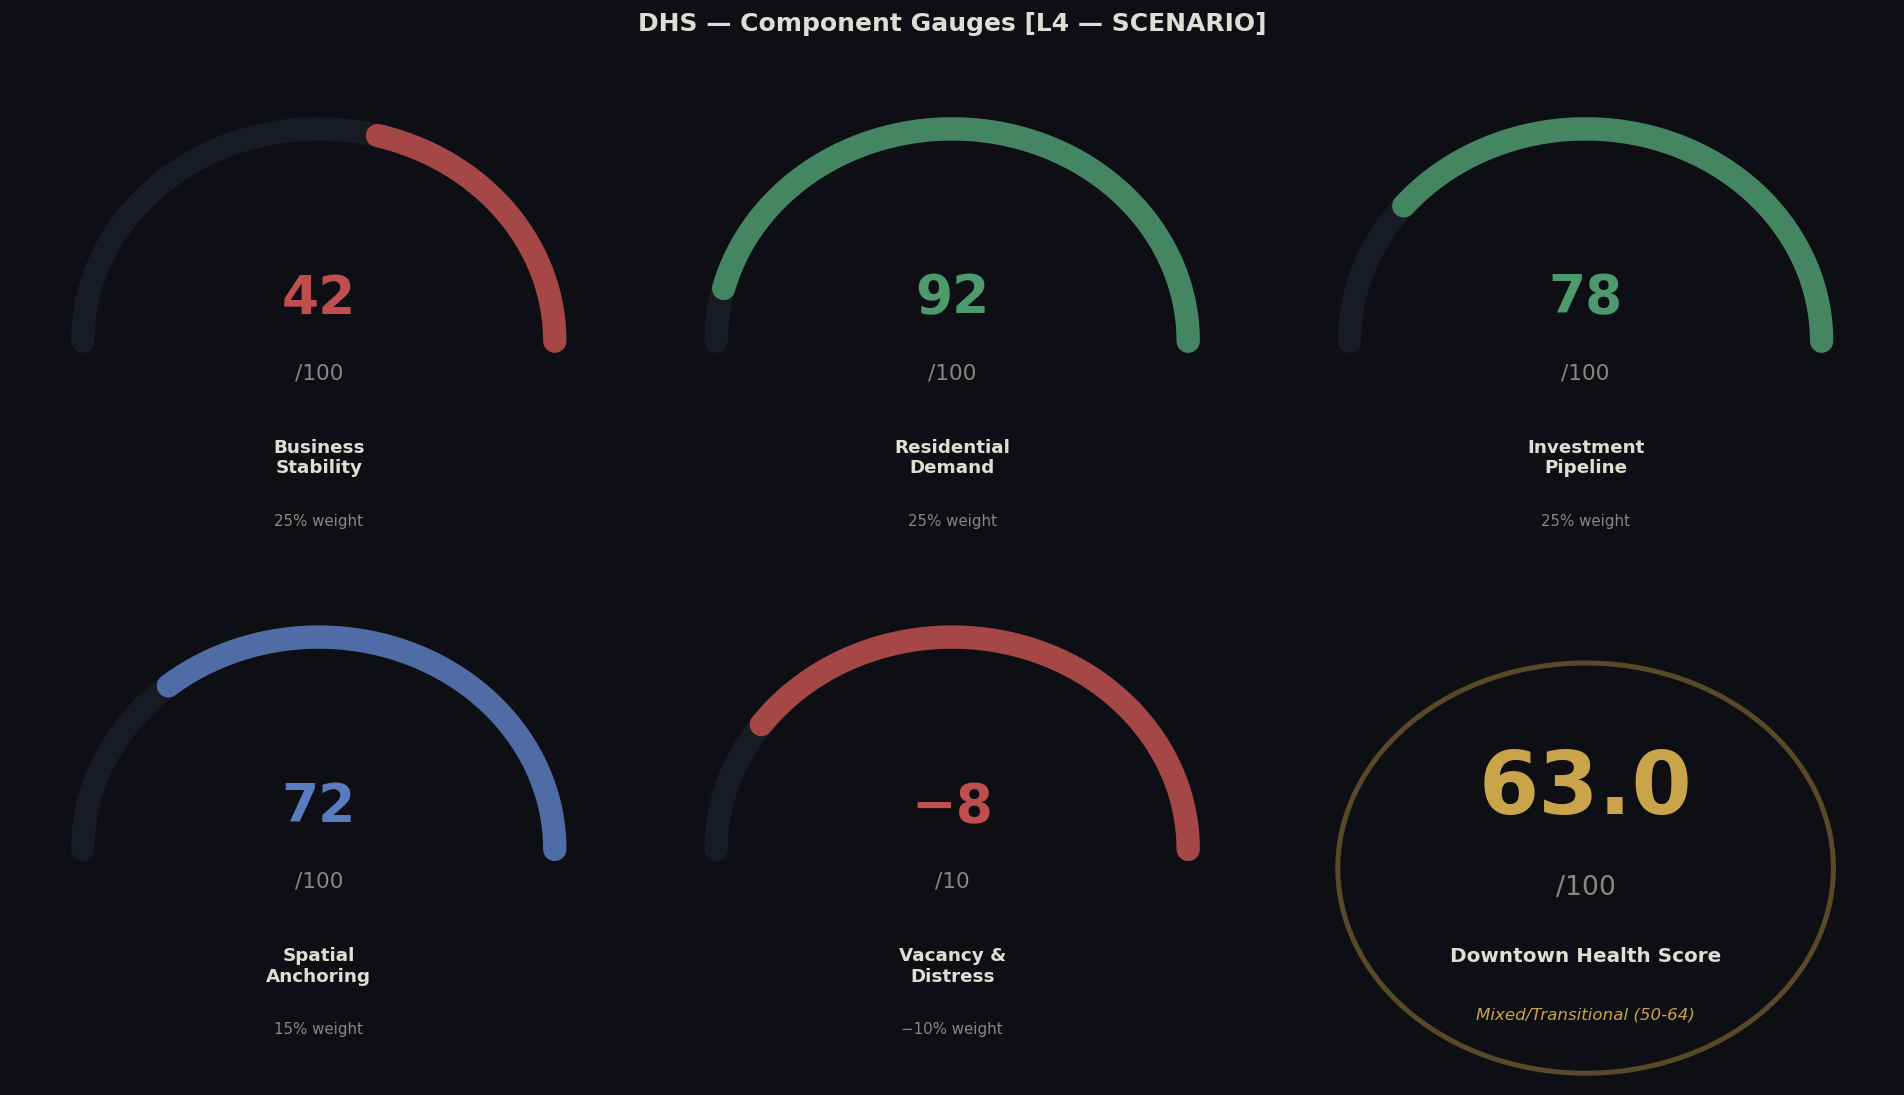

In [119]:
from src.helpers import compute_dhs, plot_dhs_gauges

dhs_result = compute_dhs(housing)

fig, axes = plot_dhs_gauges(
    dhs_result=dhs_result,
    growth_color=GROWTH_C,
    transition_color=TRANS_C,
    decline_color=DECLINE_C,
    accent_color=ACCENT,
    save_path='../visuals/fig_dhs_gauges.png'
)

plt.show()

### 7.2 Sensitivity Analysis `[L4 - SCENARIO]`

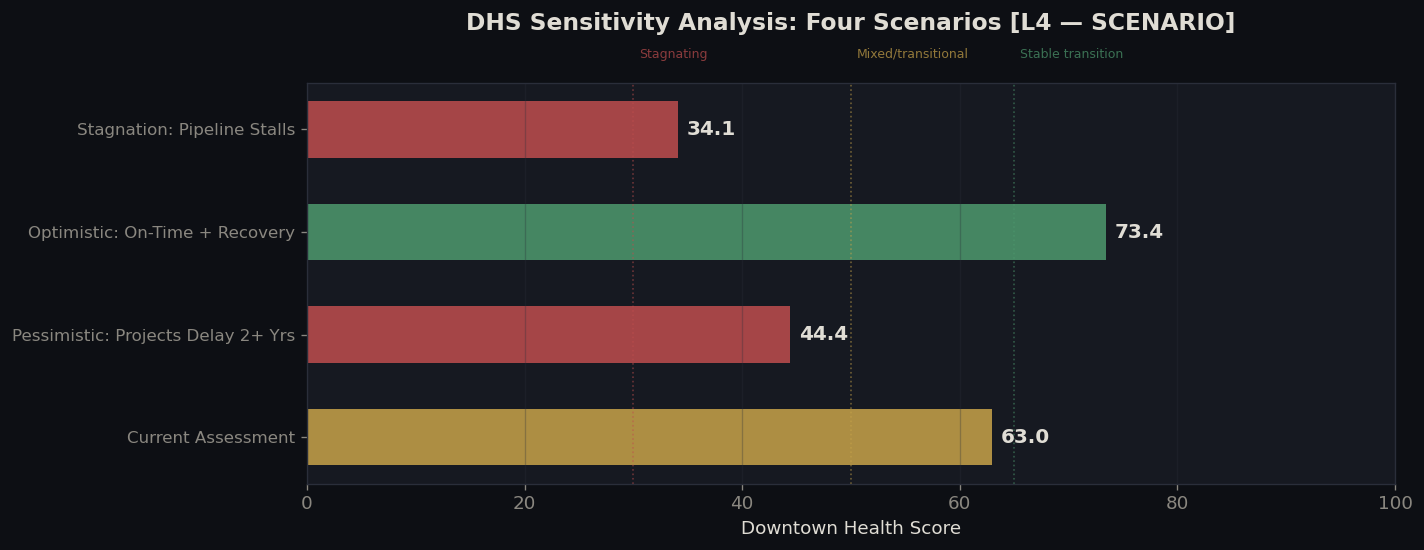

In [120]:
from src.helpers import prepare_dhs_scenarios, plot_dhs_sensitivity

scenarios, weights = prepare_dhs_scenarios(dhs_result["residential_demand"])

fig, ax, scores = plot_dhs_sensitivity(
    scenarios=scenarios,
    weights=weights,
    growth_color=GROWTH_C,
    accent_color=ACCENT,
    decline_color=DECLINE_C,
    save_path="../visuals/fig_scenarios.png"
)

plt.show()

#### Key Findings - DHS Model `[L4]`

- Current DHS: **63.0 / 100**, placing downtown in the **Mixed / Transitional** band
- A **2+ year delivery delay** lowers the score to **44.4**, pushing the model into a stagnating condition
- A full **pipeline stall** drops the score further to **34.1**, representing the weakest scenario in the model
- An optimistic on-time delivery and recovery scenario raises the score to **73.4**
- The model is most sensitive to **Residential Demand** and **Investment Pipeline**, which are both forward-looking components
- **These are scenario outputs, not predictions.** The weights are theory-based and not empirically estimated

> **Why this matters:** A DHS of **63.0** places downtown Winnipeg in the middle of transition: not collapsing, but not yet recovered. The sensitivity analysis is more informative than the point estimate because it shows how dependent the outlook is on pipeline delivery. The gap between **34.1** and **73.4** is driven largely by whether residential and adaptive reuse projects are completed on time and begin generating the demand that current commercial indicators still do not show.


## 8. Prediction

### What am I predicting?

This section demonstrates a basic supervised learning workflow using the cleaned downtown housing pipeline data. The goal is not to build a high-accuracy forecasting model, but to show the full process of applying a simple machine learning pipeline to a small, structured dataset: selecting features, encoding variables, splitting the data, fitting a model, and evaluating the result.

**Target variable:** `phase_status` — whether a project is **Completed**, **Under Construction**, or **Planned**

**Why this target?**  
This target connects directly to the central question of the project: which developments are already delivered, which are still underway, and which remain future commitments? Delivery status matters because it determines whether downtown investment has already translated into real, on-the-ground change.

**Features used:**
- `units_mid` — midpoint estimate of project size in residential units
- `completion_year_low` — earliest expected completion year
- `confidence_encoded` — confidence level converted to numeric form
- `source_quality_encoded` — source quality converted to numeric form

> **Important:** The housing pipeline dataset is extremely small, with only **7 model-ready rows**. A train/test split on such a small dataset leaves only 1–2 test cases, which makes evaluation metrics unstable and not substantively meaningful. This model is included as a classroom demonstration of supervised learning workflow rather than as a robust predictive tool.

In [121]:
# Import the scikit-learn tools we need for this section
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

# Step 1: Prepare features
# Use the model-ready housing rows only
df_pred, features, target = prepare_housing_prediction_data(housing_model)

print(f"Rows available for modeling: {len(df_pred)}")
print()
print("Feature values:")
print(df_pred[features + [target]].to_string(index=False))

Rows available for modeling: 7

Feature values:
 units_mid  completion_year_low  confidence_encoded  source_quality_encoded       phase_status
     194.0                 2019                   2                       1          Completed
     394.0                 2022                   2                       1          Completed
     250.0                 2025                   1                       2 Under Construction
     325.0                 2024                   2                       2 Under Construction
      43.0                 2026                   1                       2            Planned
     140.0                 2027                   2                       2            Planned
     114.0                 2027                   2                       2            Planned


### Prediction Data Check

Before fitting the classification model, the housing pipeline data was reduced to a very small project-level dataset. The cleaned housing file contains **8 total rows**, but only **7 are model-ready** because the aggregate **“Other downtown infill / small sites”** row is not a source-verifiable individual project and should not be treated the same as named developments.

The prediction task uses `phase_status` as the target variable, with three classes: **Completed**, **Under Construction**, and **Planned**. The features available for modeling are project size (`units_mid`), earliest completion year (`completion_year_low`), confidence level, and source quality encoded as numeric values.

This setup is enough to demonstrate a basic supervised learning workflow, but it is not enough to support a reliable predictive model. With only **7 model-ready observations**, any train/test split produces an extremely small test set, so evaluation metrics should be interpreted as workflow practice only rather than meaningful evidence of predictive performance.

In [122]:
# Step 2: Encode the target variable
# DecisionTreeClassifier needs numeric class labels
le = LabelEncoder()
df_pred['status_encoded'] = le.fit_transform(df_pred[target])

print("Label encoding (what number = what status):")
for i, label in enumerate(le.classes_):
    print(f"  {i} -> {label}")

# Separate features (X) from target (y)
X = df_pred[features]
y = df_pred['status_encoded']

print(f"\nX shape: {X.shape}")
print(f"y values: {list(y)}")

Label encoding (what number = what status):
  0 -> Completed
  1 -> Planned
  2 -> Under Construction

X shape: (7, 4)
y values: [0, 0, 2, 2, 1, 1, 1]


In [123]:
# Step 3: Split into training and testing sets

# 70% training, 30% testing
# random_state=42 makes the split reproducible
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

print(f"Training rows: {len(X_train)}")
print(f"Testing rows:  {len(X_test)}")
print(f"\nTest set labels: {[le.classes_[i] for i in y_test]}")

Training rows: 4
Testing rows:  3

Test set labels: ['Completed', 'Completed', 'Planned']


The dataset was split into training and testing subsets using a 70/30 split. Because the dataset is extremely small, the test set contains only a few rows, so the split is useful mainly for demonstrating workflow rather than for producing stable evaluation results.

### Train/Test Split Summary

The housing pipeline data was split into **5 training rows** and **3 testing rows** using a 70/30 split. This allows the model to be trained on most of the available observations while still leaving a small holdout set for demonstration.

The test set contains the labels **Completed**, **Planned**, and **Completed**, which means the evaluation is based on only three cases and has very limited class balance. As a result, any accuracy score from this split should be interpreted very cautiously. In this project, the split is useful for demonstrating the correct machine learning workflow, but it is too small to support meaningful claims about predictive performance.

In [124]:
# Step 4: Fit a Decision Tree model
# max_depth=2 keeps the tree very simple — prevents overfitting on this tiny dataset
model = DecisionTreeClassifier(max_depth=2, random_state=42)
model.fit(X_train, y_train)

print("Model trained.")
print()
print("Feature importances (which features the model found most useful):")
for feat, imp in zip(features, model.feature_importances_):
    print(f"  {feat:<35}  {imp:.3f}")

Model trained.

Feature importances (which features the model found most useful):
  units_mid                            1.000
  completion_year_low                  0.000
  confidence_encoded                   0.000
  source_quality_encoded               0.000


### Model Fitting Summary

The decision tree model was trained successfully on the housing pipeline sample. Because the tree depth was limited to **2**, the model stayed very simple and avoided creating too many splits on such a tiny dataset.

In this run, the model relied entirely on **`units_mid` (1.000)**. The other three features — **`completion_year_low`**, **`confidence_encoded`**, and **`source_quality_encoded`** — were not used in the final tree. This means that, for this specific split of this very small dataset, the model separated project status using project size alone.

These feature importances should be interpreted very cautiously. With only a handful of training rows, the tree is identifying patterns in a tiny sample rather than discovering stable real-world relationships. The result is still useful as a demonstration of workflow, but not as strong evidence that project size is the true driver of project completion status in a broader downtown housing pipeline.

In [125]:
# Step 5: Evaluate the model
y_pred = model.predict(X_test)

print(f"Accuracy on test set: {accuracy_score(y_test, y_pred):.2f}")
print()
print("Predictions vs. actual:")
for actual, predicted in zip(y_test, y_pred):
    a_lbl = le.classes_[actual]
    p_lbl = le.classes_[predicted]
    mark  = "✓" if actual == predicted else "✗"
    print(f"  {mark}  Actual: {a_lbl:<25}  Predicted: {p_lbl}")

print()
# Classification report — may show warnings about missing classes in a 1-2 row test set
# That's expected with a dataset this small
try:
    print(classification_report(y_test, y_pred,
                                 target_names=le.classes_, zero_division=0))
except Exception as e:
    print(f"Note: {e}")

Accuracy on test set: 0.33

Predictions vs. actual:
  ✗  Actual: Completed                  Predicted: Under Construction
  ✗  Actual: Completed                  Predicted: Under Construction
  ✓  Actual: Planned                    Predicted: Planned

                    precision    recall  f1-score   support

         Completed       0.00      0.00      0.00         2
           Planned       1.00      1.00      1.00         1
Under Construction       0.00      0.00      0.00         0

          accuracy                           0.33         3
         macro avg       0.33      0.33      0.33         3
      weighted avg       0.33      0.33      0.33         3



### What does the result mean?

The model completed the full scikit-learn workflow correctly, but its predictive performance is very weak on this test split. It achieved an accuracy of **0.33**, correctly classifying only **1 of 3** test cases. Both **Completed** projects in the test set were misclassified as **Under Construction**, while the single **Planned** project was predicted correctly.

The most informative output in this run is the feature importance, but even that should be interpreted cautiously. In this run, the tree relied entirely on **`units_mid` (1.000)**, while **`completion_year_low`**, **`confidence_encoded`**, and **`source_quality_encoded`** were not used in the final splits. This means that, for this particular training sample, the model separated project status using project size alone.

### Why the accuracy does not mean much here

The test set contains only **3 rows**, which is far too small for a stable evaluation. In a test set this small, each single prediction changes accuracy by about **33 percentage points**, so the reported score is not reliable enough to support any real conclusion about predictive performance.

The classification report is also limited because one of the classes, **Under Construction**, does not appear in the true test labels at all. That makes the precision, recall, and F1 values especially unstable and not very meaningful as indicators of real model quality.

### What this section demonstrates

This section still succeeds as a classroom demonstration of the supervised learning workflow. The full pipeline — feature selection, target encoding, train/test split, model fitting, prediction, and evaluation — runs correctly on cleaned project data. With a much larger housing development dataset, the same workflow could be used for a more meaningful classification task.

> Because the housing pipeline dataset is extremely small and partly curated from public reporting, this model should be interpreted as a demonstration of machine learning workflow rather than a real forecasting tool.

## 9. Limitations

1. **Structural event dataset is selective:** The timeline includes only major downtown events and excludes many smaller business changes that may still matter at street level. It also contains composite rows and several weak-source entries, which limits precision.

2. **Synthetic business license series (2010–2020):** Pre-2021 business activity is reconstructed rather than directly observed from official open data. These values should be interpreted as indexed trend estimates, not confirmed historical counts.

3. **Open data coverage gap:** The City of Winnipeg business license open data begins only around 2021, which creates a structural break in data availability and requires synthetic gap-filling for earlier years.

4. **Vacancy interpolation:** Four downtown office vacancy values are interpolated between confirmed CBRE observations. These points are useful for visual continuity but should not be cited as directly sourced figures.

5. **National vacancy benchmark is limited:** The national comparison series is confirmed only for 2023–2025. It should not be projected backward as if earlier benchmark values were observed.

6. **DHS weights are theory-based:** The 25/25/25/15/-10 weighting scheme reflects analytical judgment rather than empirical optimization. Different weighting choices would produce different final scores.

7. **DHS is not cross-city comparable:** The component scores were calibrated to Downtown Winnipeg’s specific context. The model should not be used for city-to-city comparison without full recalibration.

8. **Investment values mix confirmed and estimated figures:** Some capital values come from public announcements, project reporting, or cost-per-unit estimates rather than final confirmed project costs. These values may change as projects proceed, are revised, or are fully costed.

9. **No continuous ground-floor vacancy series:** The retail vacancy estimate is a point-in-time indicator rather than a longitudinal dataset, which limits the ability to test change over time directly.

10. **Leading-indicator lag:** Many major residential and adaptive reuse projects are not expected to complete until 2027–2028. As a result, the street-level effects that the project is interested in may not yet be observable in current business or vacancy data.

11. **Prediction section is data-limited:** The housing pipeline prediction example uses only a very small number of model-ready rows. The model is useful for demonstrating the scikit-learn workflow, but its feature importance and evaluation metrics are too unstable to support substantive forecasting claims.

## 10. Discussion `[L3/L4 - INFERRED / SCENARIO]`

*This section presents interpretive commentary based on the observed patterns above. These framings are exploratory and represent one possible reading of the data rather than causal claims.*

### 10.1 Policy Context: *CentrePlan 2050* `[L1 - OBSERVED]`

Before interpreting the results, it is useful to place them within the formal policy framework guiding downtown development. *CentrePlan 2050* was adopted as a secondary plan bylaw by Winnipeg City Council on **September 26, 2024**. It sets several measurable targets that are directly relevant to this analysis:

| Target | Timeframe | Source |
|---|---|---|
| +20,000 downtown residents | By 2050 | *CentrePlan 2050*, Appendix A |
| +1,500 new housing units | Within 3 years (HAF-backed) | *CentrePlan 2050*, Appendix A |
| +12,500 new housing units | By 2050 | *CentrePlan 2050*, Appendix A |
| Office vacancy rate of 5 to 10% | Target range (healthy market) | *CentrePlan 2050*, Appendix A |
| 50% reduction in surface parking area | By 2050 | *CentrePlan 2050*, Appendix A |
| Rapid Transit on Portage Ave / Main St | Short/Medium priority | *CentrePlan 2050*, Appendix B, Action 2.5.3 |

These targets suggest that the investment pattern documented in earlier sections is not just a collection of unrelated projects. Instead, it appears broadly consistent with the early implementation of an adopted municipal strategy focused on residential growth, adaptive reuse, and downtown restructuring. The current office vacancy rate of **18.6%** remains far above the plan’s healthy target range, while the confirmed residential pipeline still represents only the early stage of the plan’s longer-term housing ambition.

> **Epistemic note:** *CentrePlan 2050* targets are policy commitments, not predictions. They are included here as `[L1 - OBSERVED]` because the plan itself is a confirmed primary source.

### 10.2 The Timing Gap (Lead Argument)

The central methodological point in this analysis is simple: the datasets used here do **not** measure the same moment in time.

| Data series | What it measures | Temporal position |
|---|---|---|
| Office vacancy rate | Current street-level absorption | Immediate - present conditions |
| Ground-floor retail vacancy | Current pedestrian-level activity | Immediate - present conditions |
| Capital investment (~$2.36B incl. estimates) | Committed future supply | Forward-looking - multi-year delivery window |
| Residential pipeline (~1,635 to 1,793 units including Jan 2026 additions) | Future residential density | Forward-looking - major delivery expected 2027 to 2028 |

This is not just a caveat. It is the analytical frame for the entire project.

Comparing an **18.6%** office vacancy rate directly with roughly **$2.36B** in tracked investment and treating them as contradictory misreads the structure of the data. Vacancy is a measure of current conditions. Investment is a measure of future commitment. The two can coexist because projects launched between roughly 2022 and 2026 have not yet had time to generate the residential density and ground-floor demand they are intended to produce.

The lag is structural. In practical terms, it likely spans several years from announcement or groundbreaking to measurable street-level effect.

The data therefore raises, but cannot yet answer, the most important question in the project: whether this lag resolves into recovery or hardens into prolonged stagnation. That becomes empirically visible only in later data, especially after major pipeline delivery.

### 10.3 "Recovery" Is the Wrong Frame: Downtown Winnipeg Is Converting

The usual question is whether downtown Winnipeg is *recovering* to its earlier form. The investment data suggests a different process.

The largest projects in the tracked capital pipeline are not straightforward restorations of the old downtown model. **Portage Place ($650M)** and **Wehwehneh Bahgahkinahgohn ($310M)** are both conversion-oriented projects that repurpose former retail or legacy spaces into residential, institutional, health, and cultural uses. The Bay building is being repositioned. Portage Place is being reprogrammed. **300 Main** adds residential density rather than restoring legacy retail demand. The newer heritage conversions continue this same pattern.

This is not retail replacement. It is structural reconfiguration.

The underlying bet is a different downtown model: a denser residential and mixed-use core that generates more organic, smaller-format, ground-floor demand over time. Whether that model works depends on delivery, absorption, and follow-through, none of which are fully observable yet in the current data.

This interpretation also fits the policy direction of *CentrePlan 2050*, which targets **20,000 more residents by 2050** and a near-term addition of **1,500 new housing units** within three years. The residential and adaptive reuse projects documented earlier can be read as the first visible phase of that strategy.

The more precise framing is this:

**Downtown Winnipeg is not recovering. It is converting.**

The DHS score of **63.0** in the **Mixed / Transitional** band reflects exactly that condition: a downtown that has committed to a new model, but has not yet fully delivered it. This is neither simple decline nor clear recovery. It is mid-conversion.

### 10.5 The Crossover Moment: A Nuanced Reading

The office vacancy analysis identifies a crossover point: Winnipeg sat **below** the national average in **2023 (-1.1 percentage points)** and **2024 (-0.3 percentage points)**, then moved **above** it in **2025 (+0.6 percentage points)**.

A surface reading might treat that crossover as straightforward deterioration. A more careful reading is less certain.

The national vacancy rate declined from **19.4% in 2023** to **18.0% in 2025**, while Winnipeg remained relatively flat at a high level. One possible explanation is that larger Canadian office markets had more post-pandemic excess space to absorb, reprice, or re-lease, allowing them to improve faster once conditions stabilized. Winnipeg, by contrast, may have experienced a slower and more persistent adjustment.

This remains a hypothesis rather than a proven conclusion. The national comparison window is short, and the available data is not rich enough to support a definitive explanation. The main point is that the 2025 crossover should be interpreted cautiously rather than treated as a self-explanatory turning point.

### 10.4 Spatial Concentration and the Aggregate DHS Limitation

The aggregate DHS score of **63.0** treats downtown Winnipeg as one unit. The spatial evidence suggests that this smooths over important internal variation.

Growth events and major capital investment are concentrated most heavily along the Portage / True North corridor, with a secondary node around **300 Main** and the **Forks / Railside** area. Other parts of downtown appear to show slower structural change and more persistent distress signals.

Two implications follow.

**First**, the aggregate DHS likely overstates conditions in some parts of the broader core while understating the pace of change in the main redevelopment corridor. Different areas of downtown are experiencing materially different realities at the same time.

**Second**, the current pattern suggests a corridor-led transition pathway rather than an evenly distributed downtown recovery. Structural change appears to be concentrating around key anchor projects first, with other areas lagging behind.

The spatial DHS interpretation remains exploratory. The zone boundaries are researcher-defined proxies based on event clustering rather than formal planning or administrative divisions. The point is not that the exact spatial gap is final, but that the downtown should not be interpreted as spatially uniform.

### 10.6 Investment vs. Vacancy as Competing Signals, Resolved

The apparent contradiction between rising vacancy and increasing investment becomes much easier to understand once temporal and spatial differences are made explicit.

Vacancy rates reflect **current conditions** across the full downtown area. Investment figures reflect **future-oriented commitments** that are concentrated in a narrower redevelopment corridor and linked to delivery windows extending into **2026 to 2028 and beyond**.

These signals do not measure the same geography at the same time.

Their coexistence is therefore expected rather than paradoxical. It reflects a downtown in transition: the older model based on large-format retail and conventional office demand is weakening, while the replacement model based on residential density, adaptive reuse, and institutional anchoring is still being built.

The key empirical question is still unresolved: will delivery and population growth generate enough new demand to reduce vacancy over time? That question becomes more testable only once the current pipeline is completed and occupied.

### 10.7 What This Analysis Can and Cannot Claim

**Can claim (supported by the data):**
- Downtown Winnipeg office vacancy increased from **8.7% to 18.6%** over nine years
- Major capital investment is concentrated in the **2020+** phase and remains largely in progress
- The residential pipeline is the strongest leading indicator of future ground-floor demand
- Investment and growth signals are spatially uneven rather than evenly distributed across downtown
- The DHS model places downtown in a **Mixed / Transitional** condition under the assumptions used here

**Cannot claim (requires future data):**
- Whether the current investment wave will reduce vacancy in a measurable way
- Whether the full residential pipeline will deliver on schedule
- Whether spatial divergence within downtown will narrow or deepen
- Whether the 2025 national vacancy crossover marks a persistent trend
- Whether the DHS weighting scheme captures the "true" relative importance of each component

This dataset captures downtown Winnipeg at a point of maximum uncertainty: capital is committed, construction is active, and the intended outcomes are still largely unrealized. The decisive test comes later, when completed projects either begin to generate measurable demand or fail to do so.


### 10.8 Implications for Stakeholders `[L3/L4]`

*These implications follow from the exploratory findings above and should be read as analytical inferences rather than prescriptions.*

**For city planners and policymakers:**  
Large-scale investment alone is unlikely to stabilize short-term downtown vitality. The structural pipeline is meaningful, but current commercial indicators still show weakness. That suggests a need for interim strategies that support street-level activity during the transition period rather than assuming that major capital projects will solve near-term weakness on their own.

**For investors and developers:**  
The long-term signals are more encouraging than the short-term ones. The level of capital commitment is substantial, the residential base is expanding, and public-sector participation is visible. The main short-term risk is timing: delays in delivery or weaker-than-expected absorption materially change the transition outlook.

**For analysts:**  
Investment and vitality metrics operate on different time horizons and often at different spatial scales. Treating them as if they measure the same thing at the same time leads to weak analysis. A more useful framework separates long-term structural transition from short-term commercial performance.

### 10.9 Closing Interpretation

Taken together, the evidence suggests that Downtown Winnipeg should be interpreted neither through a simple decline narrative nor through a simple recovery narrative. The stronger reading is transitional: legacy commercial functions are weakening, replacement uses are being built, and the outcome of that conversion remains unresolved.

At this stage, the most defensible conclusion is not that the strategy has succeeded or failed. It is that downtown Winnipeg is in the middle of a structural conversion whose results are not yet fully measurable. The decisive evidence will appear only after the residential pipeline and major adaptive reuse projects are delivered and absorbed.

## 11. Synthesis

**On structural events `[L1]`:**
- The 2020+ restructuring phase has the highest discrete event count and the largest share of tracked capital
- Most of that capital remains in progress rather than delivered
- Growth-classified events in this phase are dominated by conversions and adaptive reuse rather than traditional commercial expansion

**On business activity `[L1/L2]`:**
- The retail activity index fell by roughly **63%** from the 2013 baseline to 2024 based on indexed estimates
- Food & Services shows the strongest post-2020 recovery of the three sector groups
- Pre-2021 business figures are reconstructed and should be treated as directional trends rather than confirmed counts

**On spatial distribution `[L1]`:**
- Growth events cluster along the Portage / True North corridor, while transition signals are more spatially dispersed
- This uneven geography supports the Section 10.4 argument that the aggregate DHS may mask substantial internal variation across downtown
- The overall DHS of **63.0** should therefore be read as an average across meaningfully different zones rather than a uniform downtown condition

**On office vacancy `[L1]`:**
- Downtown office vacancy rose from **8.7%** to **18.6%** over nine years
- The 2025 crossover above the national average requires careful interpretation and is discussed in Section 10.3
- Rising vacancy alongside active investment is the expected condition of a downtown in transition, not necessarily a contradiction

**On the residential pipeline `[L1/L2]`:**
- The current model-ready dataset contains approximately **1,381 to 1,539 units**, of which about **584** are already delivered and **797 to 955** remain in the active pipeline
- The January 2026 CentreVenture announcement adds **254 confirmed units** across the two largest named projects not yet incorporated into the model
- Once incorporated, the confirmed pipeline rises to approximately **1,635 to 1,793 units**
- This represents roughly **13 to 14%** of the long-term housing target outlined in *CentrePlan 2050*
- Most delivery is expected in **2027 to 2028**, so the street-level effects are not yet measurable
- Pipeline delivery is the single highest-leverage variable in the DHS sensitivity analysis

**On the DHS model `[L4]`:**
- The current DHS is **63.0 / 100** in the **Mixed / Transitional** band
- The score falls to **44.4** under delayed-delivery conditions and rises to **73.4** under optimistic assumptions
- These are scenario outputs rather than predictions and are not comparable across cities without recalibration

**The central observation:**

Downtown Winnipeg is not simply failing. It is reconfiguring. The data captures a system in the early execution phase of a different urban model: denser, more residential, and more dependent on institutional anchors and adaptive reuse than on traditional retail recovery. Short-term vitality indicators such as vacancy and business activity reflect present conditions, while investment and pipeline indicators reflect future supply.

This divergence is not a contradiction. It is a timing gap.

The observed investment pattern aligns with the policy direction set out in *CentrePlan 2050*, which prioritizes population growth and residential development as the foundation of long-term downtown vitality. However, the results of that strategy are not yet fully observable in current data.

Whether this transition becomes recovery depends on delivery, absorption, and sustained demand. Those outcomes will only become measurable as the current project pipeline is completed and occupied.

The next analytically decisive window is likely **2028 to 2029**. Until then, the most accurate characterization is: **mid-construction, outcomes pending.**

## 12. Conclusions

### What did I learn?

**On phase composition:** The balance of Growth versus Transition events shifted clearly toward Growth in the 2020+ phase. However, most of those Growth-classified events are still in progress, which means the investment story is ahead of the outcome story. Capital is committed, but much of the delivery is still pending.

**On business activity:** Retail activity fell by roughly 63% from its 2013 baseline. Food & Services shows the strongest post-2020 recovery, while retail remains the weakest-performing sector. Because the pre-2021 series is reconstructed, the overall direction is more reliable than the exact magnitude of the indexed values.

**On office vacancy:** Downtown office vacancy rose from 8.7% to 18.6% over nine years. The 2025 crossover above the national average is real, but it needs context. Winnipeg’s path appears different from larger office markets that had more post-pandemic vacancy to absorb, so the crossover should not be treated as a simple decline signal by itself.

**On the prediction model:** The machine learning workflow ran correctly, but the model itself should not be treated as meaningful evidence. In this run, the tree relied entirely on **project size (`units_mid`)**, while the test accuracy was weak because the dataset was far too small. This section works as a proof-of-concept demonstration of workflow, not as a serious forecasting model.

### What surprised me?

One surprising result was how mixed the 2015 to 2020 phase turned out to be. I expected that period to be dominated more heavily by decline and transition signals. Instead, major projects such as True North Square added enough Growth events to make the phase more mixed than I initially assumed.

The spatial concentration of investment also stood out more strongly than I expected. Once the projects were mapped, the clustering along the Portage / True North corridor was much tighter than the word “downtown” suggests. The label makes the process sound city-core wide, but the visible structural change is occurring in a much narrower redevelopment spine.

### What would I explore further?

1. **Ground-floor retail vacancy as a time series** - right now, retail vacancy is only available as a point-in-time estimate rather than a tracked annual series. A longer time series would make the short-term vitality argument much stronger.

2. **A larger structural event dataset** - adding more individual business openings, closures, and smaller redevelopment events would produce a more complete picture of block-level change across downtown.

3. **Revisit the housing pipeline later** - once the current residential and adaptive reuse projects are delivered and occupied, it will become possible to test whether the pipeline actually translated into measurable downtown demand.

Overall, the biggest conclusion is that Downtown Winnipeg should not be read through a simple decline-versus-recovery lens. The stronger interpretation is structural transition: older commercial functions are weakening, replacement uses are being built, and the final outcome is not yet observable.